In [89]:
%reset -f
from google.colab import files
import pandas as pd
import io


uploaded = files.upload()


filename = next(iter(uploaded))


df = pd.read_csv(io.BytesIO(uploaded[filename]), encoding='utf-8-sig')


Saving monthly_returns[1].csv to monthly_returns[1] (1).csv


In [90]:
df.head()

,DATE,Australian Listed Equity [G],Int'l Listed Equity (Hedged) [G],Int'l Listed Equity (Unhedged) [G],Australian Listed Property [G],Int'l Listed Property [G],Int'l Listed Infrastructure [G],Australian Fixed Income [D],Int'l Fixed Income (Hedged) [D],Cash [D]
0,2000-12-29 00:00:00,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
1,2001-01-31 00:00:00,0.043198,0.026030,0.138240,-0.013858,0.0,0.009438,0.015003,0.010966,0.005364
2,2001-02-28 00:00:00,-0.001874,-0.078678,-0.067859,-0.005186,0.0,-0.005876,0.006675,0.010250,0.004695
3,2001-03-30 00:00:00,-0.048466,-0.047868,-0.078172,-0.038573,0.0,-0.003365,0.005939,0.007192,0.004821
4,2001-04-30 00:00:00,0.058545,0.069750,0.047287,0.014773,0.0,0.006883,-0.009661,-0.006384,0.004350


In [100]:

date_col = 'DATE'
if date_col in df.columns:
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.set_index(date_col).sort_index()

drop_defensive = [
    'Cash [D]',
    "Int'l Fixed Income (Hedged) [D]",
    'Australian Fixed Income [D]'
]
drop_defensive = [c for c in drop_defensive if c in df.columns]
R_growth = df.drop(columns=drop_defensive, errors='ignore')
R_growth = R_growth.apply(pd.to_numeric, errors='coerce').dropna(how='any')


cut = pd.Timestamp("2021-01-29")
R     = R_growth.loc[R_growth.index <  cut]
Rtest = R_growth.loc[R_growth.index >= cut]


In [101]:
import pandas as pd, numpy as np
from io import StringIO
import numpy as np


def pca_recipe_mu_sigma(R, k=None, tau=0.75):
    """
    R : (p x n) returns, rows=assets, cols=time
    k : if None -> auto-pick advised_k by cumulative explained variance >= tau
    tau : threshold for auto-pick (default 90%)

    Returns
      mu : (p,) sample mean
      Sigma_pca : (p x p) PCA covariance (H H^T + Delta)
      advised_k : integer suggested by tau
    """
    R = np.asarray(R, float)            # p x n
    p, n = R.shape

    # mean
    rbar = R.mean(axis=1, keepdims=True)  # p x 1
    mu = rbar[:, 0]

    # sample covariance (population scale)
    Y = R - rbar
    S = (Y @ Y.T) / n
    S = 0.5*(S + S.T)

    # eigendecomposition (descending)
    vals, vecs = np.linalg.eigh(S)
    idx = vals.argsort()[::-1]
    s2  = vals[idx]
    h   = vecs[:, idx]

    # advised k by cumulative explained variance
    cvar = np.cumsum(s2) / (s2.sum() if s2.sum() > 0 else 1.0)
    advised_k = int(np.searchsorted(cvar, tau) + 1) if p > 0 else 0
    k_use = p if k is None else int(k)
    k_use = max(1, min(k_use, p))  # clamp to [1, p]

    # construct PCA covariance
    H = h[:, :k_use] * np.sqrt(s2[:k_use])
    N = S - H @ H.T
    d = np.diag(N).clip(min=0.0)
    Delta = np.diag(d)
    Sigma_pca = 0.5*((H @ H.T + Delta) + (H @ H.T + Delta).T)

    return mu.astype(float), Sigma_pca, advised_k


mu, Sigma, k = pca_recipe_mu_sigma(R.T, k=1)




In [ ]:
mu, Sigma, k = pca_recipe_mu_sigma(R.T, k=1)

asset_names = ["AU Eq", "Intl Eq (H)", "Intl Eq (UH)", "AU REIT", "GL REIT", "GL Infra"]

In [ ]:
# ===========================
#  Step 1: Train mu only
#  (Chinese explanation, English code)
# ===========================

# ---------- Parameters ----------
train_mu_years  = (2002, 2011)   # Train_μ window
valid_years     = (2012, 2014)   # Validation window
force_percent   = False          # set True if returns are in %
ewma_alphas     = [0.05, 0.10, 0.20]
shrink_lambdas  = [0.00, 0.25, 0.50, 0.75]  # 0=sample mean; 1=towards grand mean
score_primary   = "MSE"          # primary metric on validation
np.set_printoptions(suppress=True)

# ---------- Imports ----------
import numpy as np
import pandas as pd
import re
import warnings
warnings.filterwarnings("ignore")

# ---------- Select risky asset columns ----------
risky_cols = [c for c in df.columns if "[G]" in str(c)]
if not risky_cols:
    raise ValueError("No risky asset columns containing '[G]' found.")

# ---------- Date index ----------
date_cols = [c for c in df.columns if re.search(r'date', str(c), flags=re.IGNORECASE)]
data = df.copy()
if date_cols:
    try:
        data.index = pd.to_datetime(df[date_cols[0]])
    except Exception:
        pass
data = data.sort_index()

# Only keep risky columns and clean
data = data[risky_cols].copy()
for c in risky_cols:
    data[c] = pd.to_numeric(data[c], errors="coerce")
# percent -> decimal if needed
med_abs = data.replace([np.inf, -np.inf], np.nan).abs().stack().median()
if force_percent or (pd.notna(med_abs) and med_abs > 0.5):
    data = data / 100.0
data = data.dropna(how="all").fillna(0.0)

# ---------- Helper: slice by year ----------
def year_slice(df, y0, y1):
    start = pd.Timestamp(f"{y0}-01-01")
    end   = pd.Timestamp(f"{y1}-12-31")
    return df[(df.index >= start) & (df.index <= end)].copy()

train_mu_df = year_slice(data, *train_mu_years)
valid_df    = year_slice(data, *valid_years)

assert len(train_mu_df)>0 and len(valid_df)>0, "Empty slice: check your data coverage and year ranges."

print(f"Train_mu rows: {len(train_mu_df)},  Validation rows: {len(valid_df)}")

# ---------- μ estimators ----------
def mu_long_mean(train_df: pd.DataFrame) -> np.ndarray:
    """Plain time-series mean per asset."""
    return train_df.mean(axis=0).values

def mu_ewma(train_df: pd.DataFrame, alpha: float) -> np.ndarray:
    """EWMA mean per asset (last EWMA value)."""
    x = train_df.values
    w = 0.0
    m = np.zeros(x.shape[1], dtype=float)
    a = float(alpha)
    for t in range(x.shape[0]):
        m = a * x[t] + (1-a) * m
        w = a + (1-a) * w  # not used for mean normalization here (steady-state)
    return m

def mu_shrink_mean(train_df: pd.DataFrame, lam: float) -> np.ndarray:
    """
    Cross-sectional shrinkage of sample means toward grand mean.
    mu_hat = (1 - λ) * m + λ * m_bar * 1
    """
    m = train_df.mean(axis=0).values         # per-asset sample mean
    m_bar = float(m.mean())                  # grand mean across assets
    lam = float(lam)
    return (1-lam)*m + lam*m_bar

# ---------- Validation scoring ----------
def score_mu(mu_vec: np.ndarray, valid_df: pd.DataFrame) -> dict:
    """
    Treat mu_vec as constant prediction for each month in validation.
    Score: time-asset average MSE; direction hit-rate.
    """
    # broadcast to T x N
    pred = np.tile(mu_vec, (len(valid_df), 1))
    actual = valid_df.values
    mse = float(np.mean((actual - pred)**2))
    # direction hit-rate (exclude zeros)
    sign_pred = np.sign(mu_vec)
    sign_act  = np.sign(actual)
    # if mu is exactly zero for some assets, hit-rate on those columns is undefined; handle robustly
    mask = (np.abs(sign_pred) > 0)
    if mask.sum() == 0:
        hit = np.nan
    else:
        # compute per-time hit across assets that have nonzero mu
        idx = np.where(mask)[0]
        hit = float(np.mean((sign_act[:, idx] == sign_pred[idx]).mean(axis=1)))
    return {"MSE": mse, "HIT": hit}

# ---------- Grid search over μ methods on Validation ----------
candidates = []

# long_mean
mu_lm = mu_long_mean(train_mu_df)
sc_lm = score_mu(mu_lm, valid_df)
candidates.append({
    "method": "long_mean",
    "params": {},
    "mu": mu_lm,
    **sc_lm
})

# ewma_mean with alpha grid
for a in ewma_alphas:
    mu_em = mu_ewma(train_mu_df, alpha=a)
    sc_em = score_mu(mu_em, valid_df)
    candidates.append({
        "method": "ewma_mean",
        "params": {"alpha": a},
        "mu": mu_em,
        **sc_em
    })

# shrink_mean with lambda grid
for lam in shrink_lambdas:
    mu_sm = mu_shrink_mean(train_mu_df, lam=lam)
    sc_sm = score_mu(mu_sm, valid_df)
    candidates.append({
        "method": "shrink_mean",
        "params": {"lambda": lam},
        "mu": mu_sm,
        **sc_sm
    })

cand_df = pd.DataFrame(candidates)

# choose best: primary by MSE (lower), tie-break by HIT (higher)
cand_df["_rank_key"] = list(zip(cand_df["MSE"].values, -np.nan_to_num(cand_df["HIT"].values, nan=-1)))
cand_df = cand_df.sort_values(by=["MSE","HIT"], ascending=[True, False]).reset_index(drop=True)

best_row = cand_df.iloc[0].to_dict()
best_mu  = np.array(best_row["mu"])

print("\n=== μ training/selection on Validation (2012–2014) ===")
print(cand_df[["method","params","MSE","HIT"]].head(10).to_string(index=False))

print("\n>>> Selected μ method:")
print(f"Method = {best_row['method']}, Params = {best_row['params']}")
print(f"MSE = {best_row['MSE']:.6e}, HIT = {best_row['HIT']:.3f}")

# ---------- Present μ vector ----------
mu_table = pd.DataFrame({
    "Asset": risky_cols,
    "mu_estimate": best_mu
}).sort_values("mu_estimate", ascending=False).reset_index(drop=True)

print("\n=== Selected μ vector (Train_μ=2002–2011; method fixed by Validation 2012–2014) ===")
print(mu_table.to_string(index=False))

# (Optional) keep artifacts for next steps
mu_method_selected   = best_row["method"]
mu_params_selected   = best_row["params"]
mu_vector_selected   = best_mu.copy()


In [131]:
# ============================================
# DFM (PCA-based) point-in-time estimation for 2015-01 start
# - mu window: 2005-01 ~ 2014-12 (10y) --> mu_hat = Lambda * mean(F)
# - Sigma window: 2012-01 ~ 2014-12 (3y) --> Sigma_hat = Lambda Cov(F) Lambda' + diag(resid var)
# - Factor number r chosen by Bai–Ng IC (default IC2)
# - CARA closed-form for w_G*, portfolio w = (1-phi, phi w_G*)
# ============================================

# -------- User settings --------
phi          = 0.7          # fixed risky sleeve
gamma        = 1.0          # CARA risk aversion
start_date   = "2015-01-01" # investment start
mu_years     = 10           # 10y window for mu (2005-2014)
sg_years     = 3            # 3y window for Sigma (2012-2014)
r_max        = 6            # max factors to try for Bai–Ng
ic_choice    = "IC2"        # one of: "IC1","IC2","IC3"
ridge_eps    = 1e-6         # tiny ridge to ensure PD

import numpy as np
import pandas as pd
import re

# -------- Columns & dates --------
risky_cols = [c for c in df.columns if "[G]" in str(c)]
if not risky_cols:
    raise ValueError("No risky asset columns containing '[G]' were found.")

date_cols = [c for c in df.columns if re.search(r'date', str(c), flags=re.IGNORECASE)]
data = df.copy()
if date_cols:
    try:
        data.index = pd.to_datetime(df[date_cols[0]])
    except Exception:
        pass
data = data.sort_index()
data = data[risky_cols].copy()  # only risky sleeve; cash weight handled separately as (1-phi)

# numeric & %→decimal
for c in data.columns:
    data[c] = pd.to_numeric(data[c], errors="coerce")
med_abs = data.replace([np.inf,-np.inf], np.nan).abs().stack().median()
if pd.notna(med_abs) and med_abs > 0.5:
    data = data / 100.0
data = data.dropna(how="all").fillna(0.0)

# -------- Window slicing --------
start_ts = pd.Timestamp(start_date)
mu_start = start_ts - pd.DateOffset(years=mu_years)
sg_start = start_ts - pd.DateOffset(years=sg_years)

X_mu = data.loc[(data.index >= mu_start) & (data.index < start_ts), risky_cols].copy()
X_sg = data.loc[(data.index >= sg_start) & (data.index < start_ts), risky_cols].copy()
if len(X_mu) < 12 or len(X_sg) < 12:
    raise ValueError("Not enough rows for mu or Sigma windows.")

# -------- DFM via PCA: helpers --------
def pca_dfm(X: pd.DataFrame, r: int):
    """
    PCA estimator for static DFM on returns matrix X (T x N):
      X ≈ F (T x r) @ Lambda' (r x N) + E
    Returns: F (T x r), Lambda (N x r), resid_var (N-vector), V_resid_mean
    """
    Xc = X - X.mean(axis=0)  # demean over time
    U, s, Vt = np.linalg.svd(Xc.values, full_matrices=False)  # Xc = U diag(s) V'
    if r == 0:
        F = np.zeros((Xc.shape[0], 0))
        Lam = np.zeros((Xc.shape[1], 0))
        E = Xc.values
    else:
        F = U[:, :r] * s[:r]  # T x r
        Lam = Vt[:r, :].T     # N x r
        # scale convention: make factors with unit variance-ish
        # standard PCA already captures variance via s; for DFM reconstruction use F @ Lam'
        E = Xc.values - F @ Lam.T  # residuals T x N
    resid_var = E.var(axis=0, ddof=1)
    V_resid_mean = float(np.mean(E**2))
    return F, Lam, resid_var, V_resid_mean

def bai_ng_ic_grid(X: pd.DataFrame, r_max: int = 6):
    """
    Bai–Ng information criteria using PCA residual MSE:
      IC1 = ln V(n) + n*((N+T)/(N*T))*ln(N*T/(N+T))
      IC2 = ln V(n) + n*((N+T)/(N*T))*ln(min(N,T))
      IC3 = ln V(n) + n*(ln(min(N,T))/min(N,T))
    Return table and the selected r for a chosen IC.
    """
    T, N = X.shape
    out = []
    Xc = X - X.mean(axis=0)
    # precompute SVD once for efficiency
    U, s, Vt = np.linalg.svd(Xc.values, full_matrices=False)
    for r in range(0, r_max+1):
        if r == 0:
            E = Xc.values
        else:
            F = U[:, :r] * s[:r]   # T x r
            Lam = Vt[:r, :].T      # N x r
            E = Xc.values - F @ Lam.T
        Vn = np.mean(E**2)  # average squared residuals
        IC1 = np.log(Vn) + r*((N+T)/(N*T))*np.log((N*T)/(N+T))
        IC2 = np.log(Vn) + r*((N+T)/(N*T))*np.log(min(N,T))
        IC3 = np.log(Vn) + r*(np.log(min(N,T))/min(N,T))
        out.append({"r": r, "V": Vn, "IC1": IC1, "IC2": IC2, "IC3": IC3})
    return pd.DataFrame(out)

def choose_r(ic_df: pd.DataFrame, ic_name: str = "IC2"):
    row = ic_df.loc[ic_df[ic_name].idxmin()]
    return int(row["r"]), row

# -------- Choose factor numbers by Bai–Ng on each window --------
ic_mu = bai_ng_ic_grid(X_mu, r_max=r_max)
r_mu, row_mu = choose_r(ic_mu, ic_choice)

ic_sg = bai_ng_ic_grid(X_sg, r_max=r_max)
r_sg, row_sg = choose_r(ic_sg, ic_choice)

# -------- Fit DFM (PCA) on each window with the chosen r --------
F_mu, Lam_mu, resid_mu, Vmu = pca_dfm(X_mu, r=r_mu)
F_sg, Lam_sg, resid_sg, Vsg = pca_dfm(X_sg, r=r_sg)

# mu_hat = Lambda * mean(F)  (N x r  @ r-vector)
mu_hat = Lam_mu @ F_mu.mean(axis=0)

# Sigma_hat = Lambda Cov(F) Lambda' + diag(resid_var)
if r_sg == 0:
    Sigma_hat = np.diag(resid_sg)
else:
    Sigma_F = np.cov(F_sg.T, ddof=1)           # r x r
    Sigma_hat = Lam_sg @ Sigma_F @ Lam_sg.T + np.diag(resid_sg)

# tiny ridge for stability
Sigma_hat = Sigma_hat + ridge_eps * np.eye(Sigma_hat.shape[0])

# -------- Diagnostics --------
evals = np.linalg.eigvalsh(Sigma_hat)
cond  = float(evals.max() / max(evals.min(), 1e-12))
diag = {
    "mu_window_rows": int(len(X_mu)),
    "sg_window_rows": int(len(X_sg)),
    "r_mu": int(r_mu), "r_sg": int(r_sg),
    "Sigma_min_eig": float(evals.min()),
    "Sigma_max_eig": float(evals.max()),
    "Sigma_cond": cond
}

# -------- CARA closed-form for w_G* (sum=1) --------
def cara_optimal_wG(mu_vec, Sigma, gamma, phi, Fk=1.0, ridge=1e-8):
    n = len(mu_vec)
    Sig = Sigma + ridge * np.eye(n)
    Si  = np.linalg.inv(Sig)
    ones = np.ones(n)
    A = ones @ Si @ ones
    B = ones @ Si @ mu_vec
    wG = (1.0/(gamma*Fk*phi)) * (Si @ (mu_vec - (B/A)*ones)) + (1.0/A) * (Si @ ones)
    s = wG.sum()
    if s != 0:
        wG = wG / s
    return wG

wG_star = cara_optimal_wG(mu_hat, Sigma_hat, gamma=gamma, phi=phi, Fk=1.0, ridge=ridge_eps)
w_port  = np.concatenate(([1 - phi], phi * wG_star))
port_names = ["Cash"] + risky_cols

# -------- Pretty print --------
print("\n=== DFM point-in-time (2015-01 start) ===")
print(f"mu window: {X_mu.index[0].date()} ~ {X_mu.index[-1].date()},  r_mu={r_mu}")
print(f"Sigma window: {X_sg.index[0].date()} ~ {X_sg.index[-1].date()},  r_sg={r_sg}")
print("Sigma diagnostics:", diag)

mu_table = pd.DataFrame({"Asset": risky_cols, "mu_hat": mu_hat}).sort_values("mu_hat", ascending=False)
wG_table = pd.DataFrame({"Asset": risky_cols, "wG*": wG_star}).sort_values("wG*", ascending=False)
w_port_table = pd.DataFrame({"Asset": port_names, "w_port": w_port})

print("\n-- mu_hat (DFM, sorted) --")
print(mu_table.to_string(index=False))

print("\n-- w_G* (sum≈1, DFM-based Sigma) --")
print(wG_table.to_string(index=False))

print("\n-- Portfolio weights w = (1-phi, phi*w_G*) --")
print(w_port_table.to_string(index=False))

# sanity checks
unit_var = float(wG_star.T @ Sigma_hat @ wG_star)
ann_vol  = np.sqrt(unit_var) * phi * np.sqrt(12)
print(f"\nChecks: 1'w_G*={wG_star.sum():.6f}, unit_var={unit_var:.6e}, ann_vol≈{ann_vol:.2%} at phi={phi}")



=== DFM point-in-time (2015-01 start) ===
mu window: 2005-01-31 ~ 2014-12-31,  r_mu=6
Sigma window: 2012-01-31 ~ 2014-12-31,  r_sg=6
Sigma diagnostics: {'mu_window_rows': 120, 'sg_window_rows': 36, 'r_mu': 6, 'r_sg': 6, 'Sigma_min_eig': 3.095714503061993e-05, 'Sigma_max_eig': 0.0025385725649487525, 'Sigma_cond': 82.0027997555276}

-- mu_hat (DFM, sorted) --
                             Asset        mu_hat
         Int'l Listed Property [G]  1.221966e-18
Int'l Listed Equity (Unhedged) [G]  8.125425e-19
  Int'l Listed Equity (Hedged) [G]  6.053650e-19
   Int'l Listed Infrastructure [G] -2.403934e-19
    Australian Listed Property [G] -8.134628e-19
      Australian Listed Equity [G] -1.163099e-18

-- w_G* (sum≈1, DFM-based Sigma) --
                             Asset       wG*
   Int'l Listed Infrastructure [G]  1.196322
         Int'l Listed Property [G]  0.110692
      Australian Listed Equity [G]  0.023164
    Australian Listed Property [G]  0.011412
Int'l Listed Equity (Unhedged) [G]

== Fixed risky weights (box-constrained) ==
Australian Listed Equity [G]          0.3
Int'l Listed Equity (Hedged) [G]      0.3
Int'l Listed Equity (Unhedged) [G]    0.3
Australian Listed Property [G]       -0.3
Int'l Listed Property [G]             0.3
Int'l Listed Infrastructure [G]       0.1
dtype: float64
Sum = 0.9999999999999998   Bounds OK?  True
PCA rank=1, explained≈64.3%


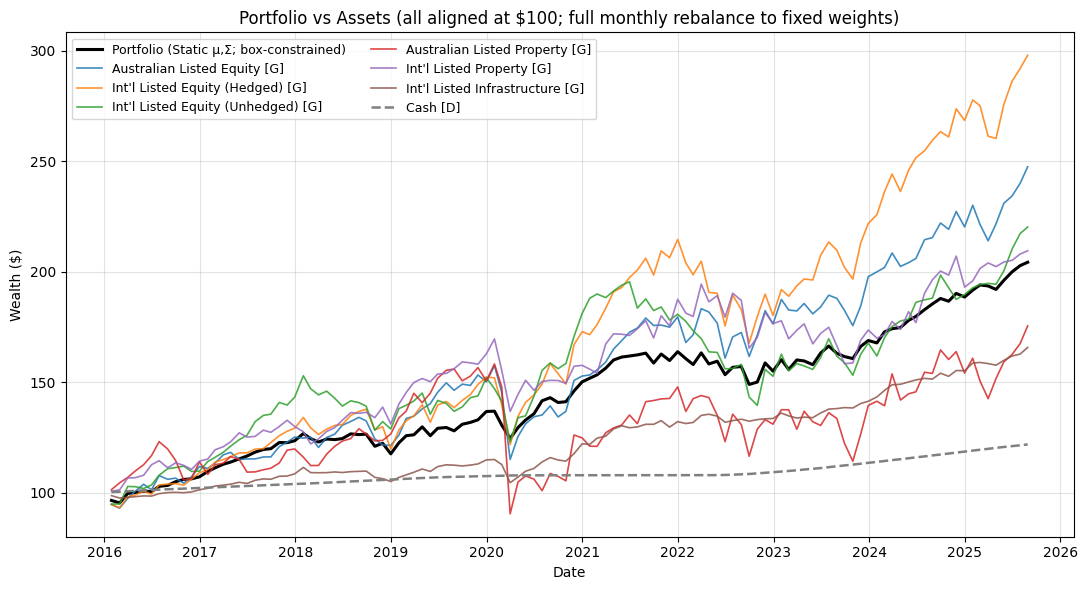

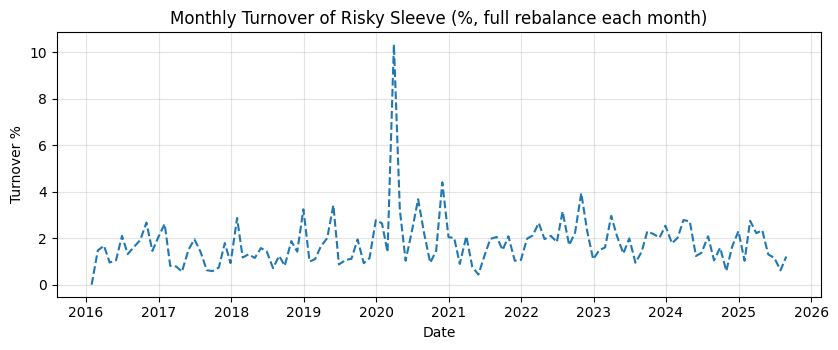


=== Static μ,Σ | Full Monthly Rebalance | Box-constrained ===
Period: 2016-01-29 → 2025-08-29, Points: 116
phi=0.7, gamma=1.0, bounds=[-0.3,0.3], PCA80% rank=1, explained≈64.3%
Ann.Return=0.0842, Vol=0.0717, Sharpe≈1.18, MaxDD=-9.06%
Avg monthly turnover (info only): 1.79%


In [132]:
# ============================================
# Static μ & Σ (frozen) + Monthly Full Rebalance
# Box constraints: sum(w_G)=1 and -0.3 <= w_i <= 0.3
# Plot portfolio vs each risky asset & Cash (all start at $100)
# ============================================

# ---------- User settings ----------
phi            = 0.7
gamma          = 1.0
start_year     = 2016
end_year       = 2025
mu_years       = 10           # pre-start window for mu (years)
sg_years       = 3            # pre-start window for Sigma (years)
explained_thr  = 0.80         # PCA cum. explained threshold
ridge_eps      = 1e-6
initial_wealth = 100.0
wmin, wmax     = -0.3, 0.3    # per-asset box

# ---------- Imports ----------
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# ---------- Identify columns & clean ----------
risky_cols = [c for c in df.columns if "[G]" in str(c)]
if not risky_cols:
    raise ValueError("No risky asset columns containing '[G]' found.")

cash_candidates = [c for c in df.columns if re.search(r'cash', str(c), flags=re.IGNORECASE)]
cash_col = cash_candidates[0] if cash_candidates else None

date_cols = [c for c in df.columns if re.search(r'date', str(c), flags=re.IGNORECASE)]
data = df.copy()
if date_cols:
    try:
        data.index = pd.to_datetime(df[date_cols[0]])
    except Exception:
        pass
data = data.sort_index()

use_cols = risky_cols + ([cash_col] if cash_col else [])
data = data[use_cols].apply(pd.to_numeric, errors="coerce")

# percent -> decimal if needed
med_abs = data.replace([np.inf, -np.inf], np.nan).abs().stack().median()
if pd.notna(med_abs) and med_abs > 0.5:
    data = data / 100.0
data = data.dropna(how="all").fillna(0.0)

# ---------- Helpers ----------
def year_slice(df, y0, y1):
    s, e = pd.Timestamp(f"{y0}-01-01"), pd.Timestamp(f"{y1}-12-31")
    return df[(df.index >= s) & (df.index <= e)].copy()

def hist_mean_mu(X_mu: pd.DataFrame):
    return X_mu.mean(axis=0).values

def pca_covariance_80(X_sg: pd.DataFrame, explained_thr=0.80, ridge_eps=1e-6):
    """
    PCA covariance reconstruction with cum explained >= threshold.
    Sigma = V_r diag(lambda_1..r) V_r' + diag(resid var) + ridge*I
    """
    Xc = X_sg - X_sg.mean(axis=0)
    T, N = Xc.shape
    if T < 2:
        S = np.diag(Xc.var(axis=0, ddof=1).values)
        return S + ridge_eps*np.eye(N), 0, 0.0
    U, s, Vt = np.linalg.svd(Xc.values, full_matrices=False)  # Xc = U diag(s) V'
    eig = (s**2) / max(T-1, 1)
    total = eig.sum()
    if total <= 0:
        S = np.diag(Xc.var(axis=0, ddof=1).values)
        return S + ridge_eps*np.eye(N), 0, 0.0
    cume = np.cumsum(eig)
    r = int(np.searchsorted(cume/total, explained_thr))
    r = max(0, min(r, min(T, N)))
    if r == 0:
        low = np.zeros((N, N))
        residuals = Xc.values
    else:
        Vr = Vt[:r, :].T
        low = Vr @ np.diag(eig[:r]) @ Vr.T
        Fr = U[:, :r] * s[:r]
        fitted = Fr @ Vr.T
        residuals = Xc.values - fitted
    diag = residuals.var(axis=0, ddof=1) if residuals.size else np.zeros(N)
    Sigma = low + np.diag(diag) + ridge_eps*np.eye(N)
    explained = float(cume[r-1]/total) if r > 0 else 0.0
    return Sigma, r, explained

def solve_box_markowitz(mu_vec, Sigma, gamma, wmin=-0.3, wmax=0.3):
    """
    Maximize mu'w - 0.5*gamma w'Sigma w
    s.t. sum(w)=1 and w in [wmin, wmax]
    """
    n = len(mu_vec)
    Sig = Sigma  # already ridged
    def obj(w): return 0.5*gamma * (w @ Sig @ w) - (mu_vec @ w)
    cons = [{'type':'eq','fun':lambda w: np.sum(w) - 1.0}]
    bounds = [(wmin, wmax)] * n
    # heuristic start: clip equal-weight to bounds, then renormalize to sum=1
    w0 = np.clip(np.ones(n)/n, wmin, wmax)
    w0 = w0 / w0.sum()
    res = minimize(obj, w0, method='SLSQP', bounds=bounds, constraints=cons,
                   options={'maxiter': 200, 'ftol': 1e-12})
    if not res.success:
        print("[WARN] optimizer:", res.message)
    w = res.x
    # small numeric cleanup
    w = np.clip(w, wmin, wmax)
    w = w / w.sum()
    return w

def pre_trade_weights(prev_wG, risky_ret, phi, cash_ret):
    risky_val = phi * prev_wG * (1.0 + risky_ret)
    cash_val  = (1.0 - phi) * (1.0 + cash_ret)
    total_val = cash_val + risky_val.sum()
    risky_weight_total = risky_val / total_val
    share = risky_weight_total.sum()
    return risky_weight_total / share if share > 0 else prev_wG

# ---------- Freeze μ & Σ at start ----------
panel = data.copy()
live  = year_slice(panel, start_year, end_year)
first_live = live.index.min()

mu_start = first_live - pd.DateOffset(years=mu_years)
sg_start = first_live - pd.DateOffset(years=sg_years)
X_mu0 = panel.loc[(panel.index >= mu_start) & (panel.index < first_live), risky_cols]
X_sg0 = panel.loc[(panel.index >= sg_start) & (panel.index < first_live), risky_cols]
if len(X_mu0) < 12 or len(X_sg0) < 12:
    raise ValueError("Not enough rows in pre-start windows to freeze mu/Sigma.")

mu_hat_fixed = hist_mean_mu(X_mu0)
Sigma_hat_fixed, r_used0, explained0 = pca_covariance_80(X_sg0, explained_thr=explained_thr, ridge_eps=ridge_eps)

# ---------- Constrained fixed wG* ----------
wG_fixed = solve_box_markowitz(mu_hat_fixed, Sigma_hat_fixed, gamma, wmin=wmin, wmax=wmax)
print("== Fixed risky weights (box-constrained) ==")
print(pd.Series(wG_fixed, index=risky_cols).round(4))
print("Sum =", wG_fixed.sum(), "  Bounds OK? ", (wG_fixed>=wmin-1e-9).all() and (wG_fixed<=wmax+1e-9).all())
print(f"PCA rank={r_used0}, explained≈{explained0:.1%}")

# ---------- Backtest (FULL monthly rebalance to same weights) ----------
dates, wealth, turnover = [], [], []
F = 1.0
prev_wG = None

for t in live.index:
    r_vec = live.loc[t, risky_cols].values
    cash_ret = float(live.loc[t, cash_col]) if cash_col else 0.0

    # info-only turnover (we ALWAYS reset to wG_fixed)
    if prev_wG is None:
        to = 0.0
    else:
        pre_wG = pre_trade_weights(prev_wG, r_vec, phi, cash_ret)
        to = 0.5 * float(np.sum(np.abs(wG_fixed - pre_wG)))
    turnover.append(to)
    prev_wG = wG_fixed.copy()

    # realized return using the FIXED target weights after full rebalance
    port_ret = (1 - phi) * cash_ret + phi * float(np.dot(wG_fixed, r_vec))
    F *= (1.0 + port_ret)
    dates.append(t)
    wealth.append(initial_wealth * F)

curve = pd.DataFrame({"wealth": wealth, "turnover": turnover},
                     index=pd.DatetimeIndex(dates, name="date"))

# ---------- Plot 1: Portfolio vs each risky asset & Cash (all start at $100) ----------
plot_idx = curve.index
live_aligned = live.loc[plot_idx, :].copy()

asset_wealth = (1.0 + live_aligned[risky_cols].fillna(0.0)).cumprod() * initial_wealth
plt.figure(figsize=(11,6))
# portfolio line
plt.plot(plot_idx, curve["wealth"], color='black', lw=2.2, label="Portfolio (Static μ,Σ; box-constrained)")
# each risky asset
for c in risky_cols:
    plt.plot(plot_idx, asset_wealth[c], lw=1.2, alpha=0.85, label=c)
# cash line
if cash_col:
    cash_wealth = (1.0 + live_aligned[cash_col].fillna(0.0)).cumprod() * initial_wealth
    plt.plot(plot_idx, cash_wealth, lw=1.8, ls='--', color='gray', label=cash_col)

plt.title("Portfolio vs Assets (all aligned at $100; full monthly rebalance to fixed weights)")
plt.xlabel("Date"); plt.ylabel("Wealth ($)")
plt.grid(True, alpha=0.35); plt.legend(ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

# ---------- Plot 2: Monthly turnover (info only) ----------
plt.figure(figsize=(8.5,3.6))
plt.plot(curve.index, np.array(curve["turnover"]) * 100.0, "--")
plt.title("Monthly Turnover of Risky Sleeve (%, full rebalance each month)")
plt.xlabel("Date"); plt.ylabel("Turnover %")
plt.grid(True, alpha=0.35)
plt.tight_layout(); plt.show()

# ---------- Perf summary ----------
if len(curve) > 1:
    ret = curve["wealth"].pct_change().dropna()
    ann = (1 + ret.mean())**12 - 1
    vol = ret.std() * np.sqrt(12)
    sharpe = ann / (vol + 1e-12)
    mdd = (curve["wealth"] / curve["wealth"].cummax() - 1).min()
else:
    ann = vol = sharpe = mdd = np.nan

print("\n=== Static μ,Σ | Full Monthly Rebalance | Box-constrained ===")
print(f"Period: {curve.index.min().date()} → {curve.index.max().date()}, Points: {len(curve)}")
print(f"phi={phi}, gamma={gamma}, bounds=[{wmin},{wmax}], PCA80% rank={r_used0}, explained≈{explained0:.1%}")
print(f"Ann.Return={ann:.4f}, Vol={vol:.4f}, Sharpe≈{sharpe:.2f}, MaxDD={mdd:.2%}")
print("Avg monthly turnover (info only): {:.2%}".format(np.nanmean(curve["turnover"])))


[Frozen] PCA rank=0, explained≈0.0%


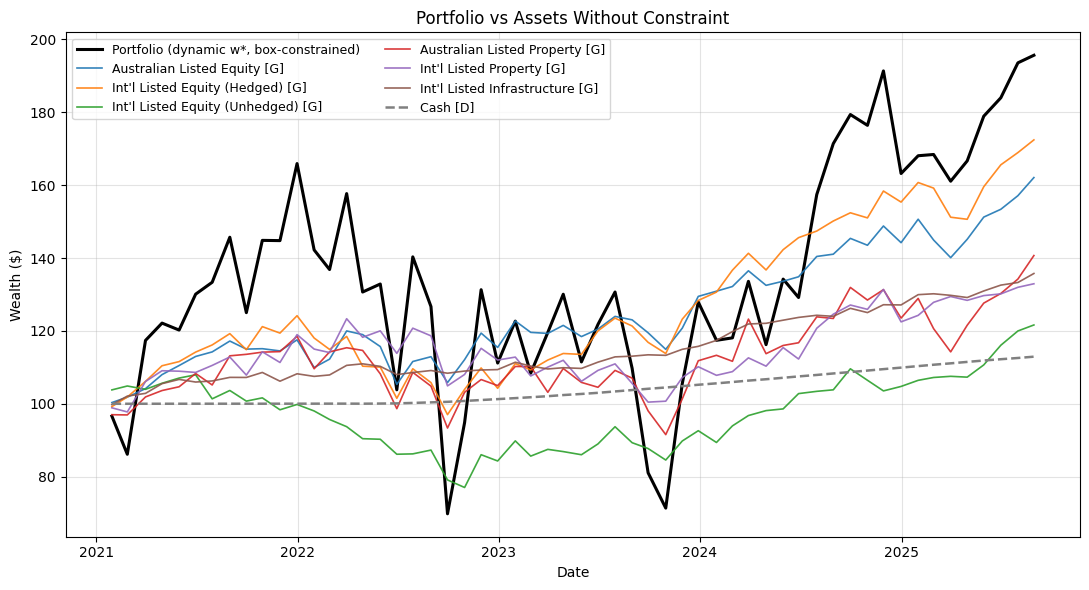

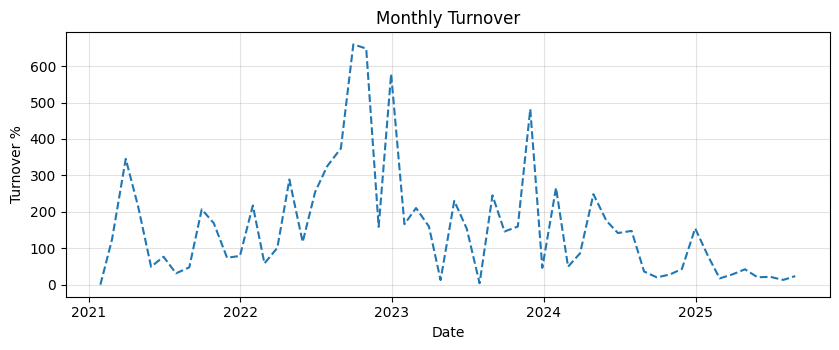


=== Fixed μ,Σ; Dynamic w* (CARA with F_k) | Box-constrained ===
Period: 2021-01-29 → 2025-08-29, Points: 56
phi=0.7, gamma=1.0, bounds=[-1000,1000], PCA80% rank=0, explained≈0.0%
Ann.Return=0.3782, Vol=0.5908, Sharpe≈0.64, MaxDD=-57.93%
Avg monthly turnover (info only): 158.21%


In [133]:
# ============================================
# Fixed mu & Sigma, BUT dynamic weights via CARA with c_k = gamma*F_k*phi
# Box constraints: -0.3 <= w_i <= 0.3, and sum(w)=1
# Full monthly rebalance each period to w_t = (1-phi, phi * wG*_t)
# ============================================

# -------- User settings --------
phi            = 0.7
gamma          = 1.0
start_year     = 2021
end_year       = 2025
mu_years       = 10           # window to freeze mu (before start)
sg_years       = 3            # window to freeze Sigma (before start)
explained_thr  = 0.80         # PCA covariance threshold
ridge_eps      = 1e-6
initial_wealth = 100.0
wmin, wmax     = -1000, 1000    # per-asset bounds

# -------- Imports --------
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# -------- Identify columns & clean --------
risky_cols = [c for c in df.columns if "[G]" in str(c)]
if not risky_cols:
    raise ValueError("No risky asset columns with '[G]' found.")

cash_candidates = [c for c in df.columns if re.search(r'cash', str(c), flags=re.IGNORECASE)]
cash_col = cash_candidates[0] if cash_candidates else None

date_cols = [c for c in df.columns if re.search(r'date', str(c), flags=re.IGNORECASE)]
data = df.copy()
if date_cols:
    try:
        data.index = pd.to_datetime(df[date_cols[0]])
    except Exception:
        pass
data = data.sort_index()

use_cols = risky_cols + ([cash_col] if cash_col else [])
data = data[use_cols].apply(pd.to_numeric, errors="coerce")

# percent -> decimal if needed
med_abs = data.replace([np.inf, -np.inf], np.nan).abs().stack().median()
if pd.notna(med_abs) and med_abs > 0.5:
    data = data / 100.0
data = data.dropna(how="all").fillna(0.0)

# -------- Helpers --------
def year_slice(df, y0, y1):
    s, e = pd.Timestamp(f"{y0}-01-01"), pd.Timestamp(f"{y1}-12-31")
    return df[(df.index>=s) & (df.index<=e)].copy()

def hist_mean_mu(X_mu: pd.DataFrame):
    return X_mu.mean(axis=0).values

def pca_covariance_80(X_sg: pd.DataFrame, explained_thr=0.80, ridge_eps=1e-6):
    """Sigma = V_r diag(lambda_1..r) V_r' + diag(resid var) + ridge*I, cum. explained >= threshold."""
    Xc = X_sg - X_sg.mean(axis=0)
    T, N = Xc.shape
    if T < 2:
        S = np.diag(Xc.var(axis=0, ddof=1).values)
        return S + ridge_eps*np.eye(N), 0, 0.0
    U, s, Vt = np.linalg.svd(Xc.values, full_matrices=False)      # Xc = U diag(s) V'
    eig = (s**2) / max(T-1, 1)
    total = eig.sum()
    if total <= 0:
        S = np.diag(Xc.var(axis=0, ddof=1).values)
        return S + ridge_eps*np.eye(N), 0, 0.0
    cume = np.cumsum(eig)
    r = int(np.searchsorted(cume/total, explained_thr))
    r = max(0, min(r, min(T, N)))
    if r == 0:
        low = np.zeros((N, N)); residuals = Xc.values
    else:
        Vr = Vt[:r, :].T
        low = Vr @ np.diag(eig[:r]) @ Vr.T
        Fr = U[:, :r] * s[:r]
        fitted = Fr @ Vr.T
        residuals = Xc.values - fitted
    diag = residuals.var(axis=0, ddof=1) if residuals.size else np.zeros(N)
    Sigma = low + np.diag(diag) + ridge_eps*np.eye(N)
    explained = float(cume[r-1] / total) if r > 0 else 0.0
    return Sigma, r, explained

def solve_box_qp(mu_vec, Sigma, c_penalty, wmin=-0.3, wmax=0.3):
    """
    Solve: max mu'w - 0.5*c_penalty * w'Sigma w
           s.t. sum(w)=1, wmin <= w_i <= wmax
    Equivalent to min 0.5*c*w'Sigma w - mu'w
    """
    n = len(mu_vec)
    Sig = Sigma
    def obj(w): return 0.5 * c_penalty * (w @ Sig @ w) - (mu_vec @ w)
    cons = [{'type':'eq', 'fun': lambda w: np.sum(w) - 1.0}]
    bnds = [(wmin, wmax)] * n
    # feasible start: clipped equal-weight normalized
    w0 = np.clip(np.ones(n)/n, wmin, wmax)
    w0 = w0 / w0.sum()
    res = minimize(obj, w0, method='SLSQP', bounds=bnds, constraints=cons,
                   options={'maxiter': 300, 'ftol': 1e-12})
    if not res.success:
        print("[WARN] QP solver:", res.message)
    w = res.x
    # numerical cleanup
    w = np.clip(w, wmin, wmax)
    w = w / w.sum()
    return w

def pre_trade_weights(prev_wG, risky_ret, phi, cash_ret):
    """Weights of risky sleeve BEFORE rebalancing (for turnover)."""
    risky_val = phi * prev_wG * (1.0 + risky_ret)
    cash_val  = (1.0 - phi) * (1.0 + cash_ret)
    total_val = cash_val + risky_val.sum()
    risky_weight_total = risky_val / total_val
    share = risky_weight_total.sum()
    return risky_weight_total / share if share > 0 else prev_wG

# -------- Freeze mu & Sigma once (before live start) --------
panel = data.copy()
live  = year_slice(panel, start_year, end_year)
first_live = live.index.min()

mu_start = first_live - pd.DateOffset(years=mu_years)
sg_start = first_live - pd.DateOffset(years=sg_years)
X_mu0 = panel.loc[(panel.index>=mu_start) & (panel.index<first_live), risky_cols]
X_sg0 = panel.loc[(panel.index>=sg_start) & (panel.index<first_live), risky_cols]
if len(X_mu0) < 12 or len(X_sg0) < 12:
    raise ValueError("Not enough rows in pre-start windows to freeze mu/Sigma.")

mu_hat = hist_mean_mu(X_mu0)
Sigma_hat, r_used0, explained0 = pca_covariance_80(X_sg0, explained_thr=explained_thr, ridge_eps=ridge_eps)

print(f"[Frozen] PCA rank={r_used0}, explained≈{explained0:.1%}")

# -------- Rolling: solve QP each month with c_k = gamma*F_k*phi --------
dates, wealth, turnover = [], [], []
F = 1.0
prev_wG = None

for t in live.index:
    # effective risk penalty this month
    c_k = gamma * F * phi

    # constrained optimal risky weights for this month
    wG_k = solve_box_qp(mu_hat, Sigma_hat, c_penalty=c_k, wmin=wmin, wmax=wmax)

    # info-only turnover
    r_vec = live.loc[t, risky_cols].values
    cash_ret = float(live.loc[t, cash_col]) if cash_col else 0.0
    if prev_wG is None:
        to = 0.0
    else:
        pre_wG = pre_trade_weights(prev_wG, r_vec, phi, cash_ret)
        to = 0.5 * float(np.sum(np.abs(wG_k - pre_wG)))
    turnover.append(to)
    prev_wG = wG_k.copy()

    # realized return after full rebalance to (1-phi, phi*wG_k)
    port_ret = (1 - phi) * cash_ret + phi * float(np.dot(wG_k, r_vec))
    F *= (1.0 + port_ret)
    dates.append(t)
    wealth.append(initial_wealth * F)

curve = pd.DataFrame({"wealth": wealth, "turnover": turnover},
                     index=pd.DatetimeIndex(dates, name="date"))

# -------- Plot: portfolio vs assets & cash (start at $100) --------
plot_idx = curve.index
live_aligned = live.loc[plot_idx, :].copy()
asset_wealth = (1.0 + live_aligned[risky_cols].fillna(0.0)).cumprod() * initial_wealth

plt.figure(figsize=(11,6))
plt.plot(plot_idx, curve["wealth"], color='black', lw=2.2, label="Portfolio (dynamic w*, box-constrained)")
for c in risky_cols:
    plt.plot(plot_idx, asset_wealth[c], lw=1.2, alpha=0.9, label=c)
if cash_col:
    cash_wealth = (1.0 + live_aligned[cash_col].fillna(0.0)).cumprod() * initial_wealth
    plt.plot(plot_idx, cash_wealth, lw=1.8, ls='--', color='gray', label=cash_col)
plt.title("Portfolio vs Assets Without Constraint")
plt.xlabel("Date"); plt.ylabel("Wealth ($)")
plt.grid(True, alpha=0.35); plt.legend(ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

# -------- Plot: monthly turnover --------
plt.figure(figsize=(8.5,3.6))
plt.plot(curve.index, np.array(curve["turnover"]) * 100.0, "--")
plt.title("Monthly Turnover")
plt.xlabel("Date"); plt.ylabel("Turnover %")
plt.grid(True, alpha=0.35)
plt.tight_layout(); plt.show()

# -------- Quick performance summary --------
if len(curve) > 1:
    ret = curve["wealth"].pct_change().dropna()
    ann = (1 + ret.mean())**12 - 1
    vol = ret.std() * np.sqrt(12)
    sharpe = ann / (vol + 1e-12)
    mdd = (curve["wealth"] / curve["wealth"].cummax() - 1).min()
else:
    ann = vol = sharpe = mdd = np.nan

print("\n=== Fixed μ,Σ; Dynamic w* (CARA with F_k) | Box-constrained ===")
print(f"Period: {curve.index.min().date()} → {curve.index.max().date()}, Points: {len(curve)}")
print(f"phi={phi}, gamma={gamma}, bounds=[{wmin},{wmax}], PCA80% rank={r_used0}, explained≈{explained0:.1%}")
print(f"Ann.Return={ann:.4f}, Vol={vol:.4f}, Sharpe≈{sharpe:.2f}, MaxDD={mdd:.2%}")
print("Avg monthly turnover (info only): {:.2%}".format(np.nanmean(curve['turnover'])))


[Frozen] PCA rank=1, explained≈63.7%


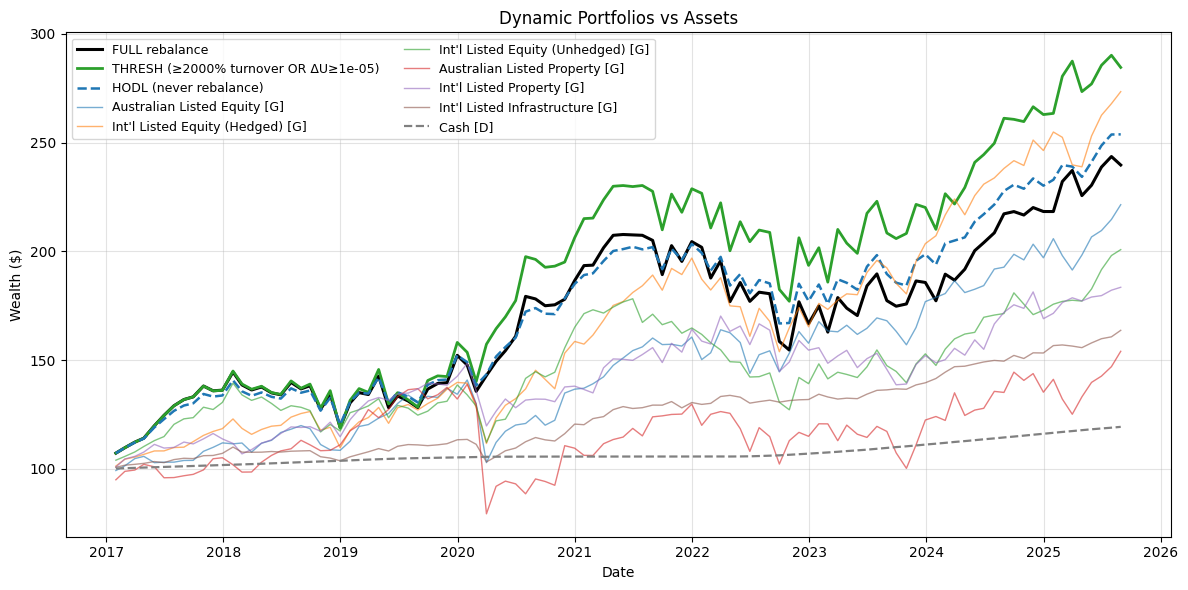

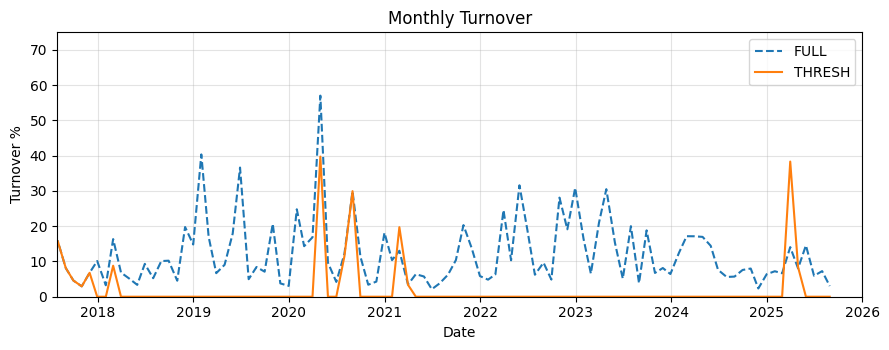

FULL    | Ann=0.1135  Vol=0.1669  Sharpe≈0.68  MaxDD=-25.58%
THRESH  | Ann=0.1396  Vol=0.1867  Sharpe≈0.75  MaxDD=-23.12%
HODL    | Ann=0.1150  Vol=0.1308  Sharpe≈0.88  MaxDD=-17.97%

[Params] phi=0.7, gamma=1.0, bounds=[-1,1], PCA80% rank=1, explained≈63.7%
[THRESH] triggers: turnover≥2000% OR utility gap≥1e-05


In [134]:
# ============================================
# Fixed μ, Σ (frozen before backtest), but dynamic w*_k via c_k=γ F_k φ
# Box constraints: -0.3 <= w_i <= 0.3, sum(w)=1
# Three portfolios with independent wealth paths:
#   1) FULL   : rebalance to w*_k every month
#   2) HODL   : buy-and-hold (only initial buy), never rebalance
#   3) THRESH : rebalance only if (turnover-needed >= τ_w) or (utility-gap >= τ_U)
#   -> Pre-trade weight is last month's post-trade weight drifted by last month's realized returns
# Plots: portfolios vs each risky asset & Cash (all aligned to $100)
# ============================================

# -------- User settings --------
phi            = 0.7
gamma          = 1.0
start_year     = 2017
end_year       = 2025
mu_years       = 10           # window to freeze mu (years before start)
sg_years       = 3            # window to freeze Sigma (years before start)
explained_thr  = 0.80         # PCA covariance threshold
ridge_eps      = 1e-6
initial_wealth = 100.0
wmin, wmax     = -1, 1    # per-asset bounds

# Thresholds for THRESH strategy (tune to your taste)
thresh_weight  = 20   # trigger if 0.5 * L1(w* - w_pre) >= 10%
thresh_utility = 1e-5   # or if utility gap >= this value

# -------- Imports --------
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# -------- Identify columns & clean --------
risky_cols = [c for c in df.columns if "[G]" in str(c)]
if not risky_cols:
    raise ValueError("No risky asset columns with '[G]' found in df.")

cash_candidates = [c for c in df.columns if re.search(r'cash', str(c), flags=re.IGNORECASE)]
cash_col = cash_candidates[0] if cash_candidates else None

date_cols = [c for c in df.columns if re.search(r'date', str(c), flags=re.IGNORECASE)]
data = df.copy()
if date_cols:
    try:
        data.index = pd.to_datetime(df[date_cols[0]])
    except Exception:
        pass
data = data.sort_index()

use_cols = risky_cols + ([cash_col] if cash_col else [])
data = data[use_cols].apply(pd.to_numeric, errors="coerce")

# percent -> decimal if needed
med_abs = data.replace([np.inf, -np.inf], np.nan).abs().stack().median()
if pd.notna(med_abs) and med_abs > 0.5:
    data = data / 100.0
data = data.dropna(how="all").fillna(0.0)

# -------- Helpers --------
def year_slice(df, y0, y1):
    s, e = pd.Timestamp(f"{y0}-01-01"), pd.Timestamp(f"{y1}-12-31")
    return df[(df.index>=s) & (df.index<=e)].copy()

def hist_mean_mu(X_mu: pd.DataFrame):
    return X_mu.mean(axis=0).values

def pca_covariance_80(X_sg: pd.DataFrame, explained_thr=0.80, ridge_eps=1e-6):
    """Σ = V_r diag(λ_1..λ_r) V_r' + diag(resid var) + ridge*I, with cum explained ≥ threshold."""
    Xc = X_sg - X_sg.mean(axis=0)
    T, N = Xc.shape
    if T < 2:
        S = np.diag(Xc.var(axis=0, ddof=1).values)
        return S + ridge_eps*np.eye(N), 0, 0.0
    U, s, Vt = np.linalg.svd(Xc.values, full_matrices=False)  # Xc = U diag(s) V'
    eig = (s**2) / max(T-1, 1)
    total = eig.sum()
    if total <= 0:
        S = np.diag(Xc.var(axis=0, ddof=1).values)
        return S + ridge_eps*np.eye(N), 0, 0.0
    cume = np.cumsum(eig)
    r = int(np.searchsorted(cume/total, explained_thr))
    r = max(0, min(r, min(T, N)))
    if r == 0:
        low = np.zeros((N, N)); residuals = Xc.values
    else:
        Vr = Vt[:r, :].T
        low = Vr @ np.diag(eig[:r]) @ Vr.T
        Fr = U[:, :r] * s[:r]
        fitted = Fr @ Vr.T
        residuals = Xc.values - fitted
    diag = residuals.var(axis=0, ddof=1) if residuals.size else np.zeros(N)
    Sigma = low + np.diag(diag) + ridge_eps*np.eye(N)
    explained = float(cume[r-1]/total) if r>0 else 0.0
    return Sigma, r, explained

def solve_box_qp(mu_vec, Sigma, c_penalty, wmin=-0.3, wmax=0.3):
    """
    Solve: max μ'w - 0.5*c_penalty * w'Σ w    s.t. sum(w)=1, w∈[wmin,wmax].
    Equivalent to min 0.5*c*w'Σ w - μ'w (strictly convex).
    """
    n = len(mu_vec)
    Sig = Sigma
    def obj(w): return 0.5 * c_penalty * (w @ Sig @ w) - (mu_vec @ w)
    cons = [{'type':'eq','fun':lambda w: np.sum(w)-1.0}]
    bnds = [(wmin, wmax)] * n
    w0 = np.clip(np.ones(n)/n, wmin, wmax)
    w0 = w0 / w0.sum()
    res = minimize(obj, w0, method='SLSQP', bounds=bnds, constraints=cons,
                   options={'maxiter': 300, 'ftol': 1e-12})
    if not res.success:
        print("[WARN] QP solver:", res.message)
    w = np.clip(res.x, wmin, wmax)
    w = w / w.sum()
    return w

def drift_weights(w_post, r_prev_vec, phi, r_prev_cash):
    """
    From last month's POST-trade risky-sleeve weights w_post,
    produce THIS month's PRE-trade risky-sleeve weights w_pre using LAST month's realized returns.
    """
    risky_val = phi * w_post * (1.0 + (0.0 if r_prev_vec is None else r_prev_vec))
    cash_val  = (1.0 - phi) * (1.0 + (0.0 if r_prev_cash is None else r_prev_cash))
    total = cash_val + risky_val.sum()
    risky_weight_total = risky_val / total
    share = risky_weight_total.sum()
    return (risky_weight_total / share) if share > 0 else w_post

def utility_value(mu_vec, Sigma, c_penalty, w):
    return float(mu_vec @ w - 0.5 * c_penalty * (w @ Sigma @ w))

# -------- Freeze μ & Σ once (before live start) --------
panel = data.copy()
live  = year_slice(panel, start_year, end_year)
first_live = live.index.min()

mu_start = first_live - pd.DateOffset(years=mu_years)
sg_start = first_live - pd.DateOffset(years=sg_years)
X_mu0 = panel.loc[(panel.index>=mu_start) & (panel.index<first_live), risky_cols]
X_sg0 = panel.loc[(panel.index>=sg_start) & (panel.index<first_live), risky_cols]
if len(X_mu0) < 12 or len(X_sg0) < 12:
    raise ValueError("Not enough rows in pre-start windows to freeze mu/Sigma.")

mu_hat = hist_mean_mu(X_mu0)
Sigma_hat, r_used0, explained0 = pca_covariance_80(X_sg0, explained_thr=explained_thr, ridge_eps=ridge_eps)
print(f"[Frozen] PCA rank={r_used0}, explained≈{explained0:.1%}")

# -------- Prepare three independent strategies --------
dates = list(live.index)
n = len(risky_cols)
eq_w = np.ones(n) / n  # first-month pre-trade placeholder

# Containers
wealth_full, wealth_hodl, wealth_thr = [], [], []
turn_full, turn_thr = [], []

# FULL state
F_full = 1.0
w_post_full = None
r_prev_vec_full = None
r_prev_cash_full = None

# HODL state
F_hodl = 1.0
w_post_hodl = None
r_prev_vec_hodl = None
r_prev_cash_hodl = None

# THRESH state
F_thr = 1.0
w_post_thr = None
r_prev_vec_thr = None
r_prev_cash_thr = None

for t in dates:
    r_vec_t = live.loc[t, risky_cols].values
    r_cash_t = float(live.loc[t, cash_col]) if cash_col else 0.0

    # ---------- FULL ----------
    # pre-trade weight from last month
    w_pre_full = eq_w if w_post_full is None else drift_weights(w_post_full, r_prev_vec_full, phi, r_prev_cash_full)
    # period-specific risk penalty
    c_full = gamma * F_full * phi
    # optimal this month
    w_star_full = solve_box_qp(mu_hat, Sigma_hat, c_penalty=c_full, wmin=wmin, wmax=wmax)
    # trade fully to w_star
    to_full = 0.5 * float(np.sum(np.abs(w_star_full - w_pre_full)))
    turn_full.append(to_full)
    w_post_full = w_star_full.copy()
    # realize return
    ret_full = (1 - phi) * r_cash_t + phi * float(np.dot(w_post_full, r_vec_t))
    F_full *= (1.0 + ret_full)
    wealth_full.append(initial_wealth * F_full)
    # store last month realized for next drift
    r_prev_vec_full, r_prev_cash_full = r_vec_t, r_cash_t

    # ---------- HODL ----------
    if w_post_hodl is None:
        # initial buy: use c0 = γ F φ with F=1
        c0 = gamma * F_hodl * phi
        w_post_hodl = solve_box_qp(mu_hat, Sigma_hat, c_penalty=c0, wmin=wmin, wmax=wmax)
    # never trade afterwards; just drift
    w_pre_hodl = drift_weights(w_post_hodl, r_prev_vec_hodl, phi, r_prev_cash_hodl) if r_prev_vec_hodl is not None else w_post_hodl
    w_post_hodl = w_pre_hodl.copy()
    ret_hodl = (1 - phi) * r_cash_t + phi * float(np.dot(w_post_hodl, r_vec_t))
    F_hodl *= (1.0 + ret_hodl)
    wealth_hodl.append(initial_wealth * F_hodl)
    r_prev_vec_hodl, r_prev_cash_hodl = r_vec_t, r_cash_t

    # ---------- THRESH ----------
    w_pre_thr = eq_w if w_post_thr is None else drift_weights(w_post_thr, r_prev_vec_thr, phi, r_prev_cash_thr)
    c_thr = gamma * F_thr * phi
    w_star_thr = solve_box_qp(mu_hat, Sigma_hat, c_penalty=c_thr, wmin=wmin, wmax=wmax)
    # signals
    need_turn = 0.5 * float(np.sum(np.abs(w_star_thr - w_pre_thr)))
    util_star = utility_value(mu_hat, Sigma_hat, c_thr, w_star_thr)
    util_pre  = utility_value(mu_hat, Sigma_hat, c_thr, w_pre_thr)
    gap_util  = util_star - util_pre
    # trade only if threshold met
    if (need_turn >= thresh_weight) or (gap_util >= thresh_utility):
        w_post_thr = w_star_thr.copy()
        to_thr = need_turn
    else:
        w_post_thr = w_pre_thr.copy()
        to_thr = 0.0
    turn_thr.append(to_thr)
    ret_thr = (1 - phi) * r_cash_t + phi * float(np.dot(w_post_thr, r_vec_t))
    F_thr *= (1.0 + ret_thr)
    wealth_thr.append(initial_wealth * F_thr)
    r_prev_vec_thr, r_prev_cash_thr = r_vec_t, r_cash_t

# -------- Assemble curves --------
idx = pd.DatetimeIndex(dates, name="date")
curve = pd.DataFrame({"FULL": wealth_full, "THRESH": wealth_thr, "HODL": wealth_hodl}, index=idx)
turn  = pd.DataFrame({"FULL": turn_full, "THRESH": turn_thr}, index=idx)

# -------- Plot: portfolios vs assets & cash (aligned at $100) --------
live_aligned = live.loc[idx, :].copy()
asset_wealth = (1.0 + live_aligned[risky_cols].fillna(0.0)).cumprod() * initial_wealth

plt.figure(figsize=(12,6))
plt.plot(idx, curve["FULL"],   lw=2.2, color='black',       label="FULL rebalance")
plt.plot(idx, curve["THRESH"], lw=2.0, color='tab:green',   label=f"THRESH (≥{thresh_weight:.0%} turnover OR ΔU≥{thresh_utility:g})")
plt.plot(idx, curve["HODL"],   lw=1.8, ls='--', color='tab:blue', label="HODL (never rebalance)")
for c in risky_cols:
    plt.plot(idx, asset_wealth[c], lw=1.0, alpha=0.6, label=c)
if cash_col:
    cash_wealth = (1.0 + live_aligned[cash_col].fillna(0.0)).cumprod() * initial_wealth
    plt.plot(idx, cash_wealth, lw=1.6, ls='--', color='gray', label=cash_col)
plt.title("Dynamic Portfolios vs Assets")
plt.xlabel("Date"); plt.ylabel("Wealth ($)")
plt.grid(True, alpha=0.35); plt.legend(ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

# -------- Plot: monthly turnover (FULL & THRESH) --------
plt.figure(figsize=(9,3.6))
plt.plot(idx, turn["FULL"]*100.0,  "--", label="FULL")
plt.plot(idx, turn["THRESH"]*100.0, "-",  label="THRESH")
plt.title("Monthly Turnover")
plt.xlabel("Date"); plt.ylabel("Turnover %")
plt.grid(True, alpha=0.35); plt.legend()
plt.xlim(pd.Timestamp("2017-07-28"), pd.Timestamp("2026-01-01"))
plt.ylim(0,75)
plt.tight_layout(); plt.show()


# -------- Quick performance summary --------
def perf(series):
    r = series.pct_change().dropna()
    if len(r)==0: return np.nan, np.nan, np.nan, np.nan
    ann = (1 + r.mean())**12 - 1
    vol = r.std() * np.sqrt(12)
    sharpe = ann / (vol + 1e-12)
    mdd = (series/series.cummax()-1).min()
    return ann, vol, sharpe, mdd

for name in ["FULL", "THRESH", "HODL"]:
    a,v,s,m = perf(curve[name])
    print(f"{name:7s} | Ann={a:.4f}  Vol={v:.4f}  Sharpe≈{s:.2f}  MaxDD={m:.2%}")

print(f"\n[Params] phi={phi}, gamma={gamma}, bounds=[{wmin},{wmax}], PCA80% rank={r_used0}, explained≈{explained0:.1%}")
print(f"[THRESH] triggers: turnover≥{thresh_weight:.0%} OR utility gap≥{thresh_utility:g}")


[Frozen] PCA rank=1, explained≈63.7%


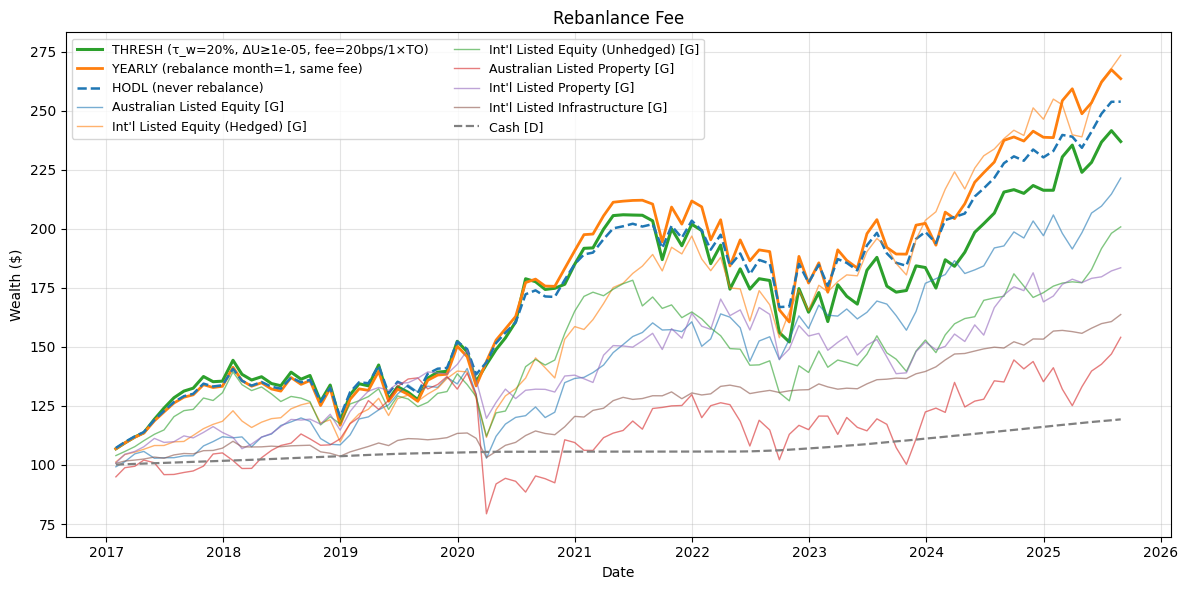

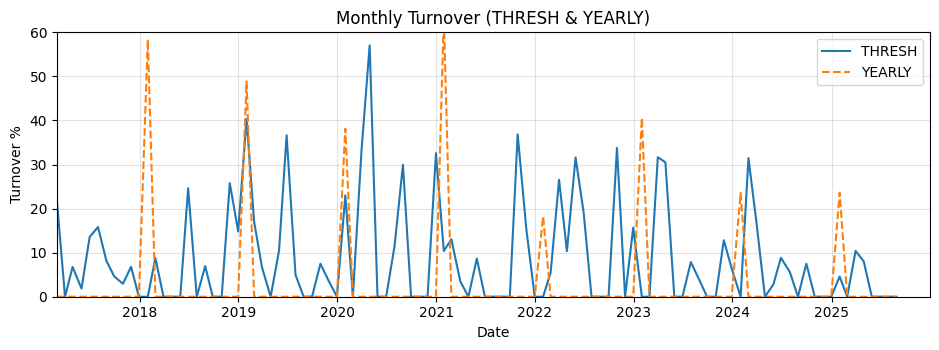

THRESH  | Ann=0.1128  Vol=0.1694  Sharpe≈0.67  MaxDD=-26.15%
YEARLY  | Ann=0.1267  Vol=0.1697  Sharpe≈0.75  MaxDD=-24.31%
HODL    | Ann=0.1150  Vol=0.1308  Sharpe≈0.88  MaxDD=-17.97%

[Params] phi=0.7, gamma=1.0, bounds=[-1.0,1.0]
PCA80% rank=1, explained≈63.7%
THRESH: τ_w=20%, ΔU≥1e-05, trading cost rate=0.0020 per 1×TO on total wealth
YEARLY rebalance month = 1 (same fee rule as THRESH)


In [109]:
# ============================================
# Fixed μ, Σ (frozen) + dynamic w* via c_k=γ F_k φ
# Three strategies with independent wealth paths:
#   HODL   : buy-and-hold (never rebalance)
#   THRESH : conditional rebalance with costs applied to wealth
#   YEARLY : rebalance once per year (same cost rule)
# Σ via PCA(>=80% explained) + diag(resid) + ridge
# ============================================

# -------- User settings --------
phi            = 0.7
gamma          = 1.0
start_year     = 2017
end_year       = 2025
mu_years       = 10            # years to estimate μ before start
sg_years       = 3             # years to estimate Σ before start
explained_thr  = 0.80          # PCA covariance threshold
ridge_eps      = 1e-6
initial_wealth = 100.0

# box bounds for risky-sleeve weights
wmin, wmax     = -1.0, 1.0

# THRESH triggers (weight threshold accepts percent or fraction)
thresh_weight  = 20            # 20 => 20% (if >1 it will be divided by 100)
thresh_utility = 1e-5          # utility gap trigger

# trading cost (applied when THRESH/YEARLY actually trade)
tc_rate        = 0.002         # e.g., 20 bps per 1×turnover (on TOTAL wealth)

# -------- Imports --------
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize

# -------- Identify columns & clean df --------
# Expect df already loaded by you; risky assets columns contain "[G]", cash column contains "Cash"
risky_cols = [c for c in df.columns if "[G]" in str(c)]
if not risky_cols:
    raise ValueError("No risky asset columns with '[G]' found in df.")

cash_candidates = [c for c in df.columns if re.search(r'cash', str(c), flags=re.IGNORECASE)]
cash_col = cash_candidates[0] if cash_candidates else None

date_cols = [c for c in df.columns if re.search(r'date', str(c), flags=re.IGNORECASE)]
data = df.copy()
if date_cols:
    try:
        data.index = pd.to_datetime(df[date_cols[0]])
    except Exception:
        pass
data = data.sort_index()

use_cols = risky_cols + ([cash_col] if cash_col else [])
data = data[use_cols].apply(pd.to_numeric, errors="coerce")
# percent -> decimal if needed
med_abs = data.replace([np.inf, -np.inf], np.nan).abs().stack().median()
if pd.notna(med_abs) and med_abs > 0.5:
    data = data / 100.0
data = data.dropna(how="all").fillna(0.0)

def year_slice(df, y0, y1):
    s, e = pd.Timestamp(f"{y0}-01-01"), pd.Timestamp(f"{y1}-12-31")
    return df[(df.index>=s) & (df.index<=e)].copy()

# -------- Estimators: μ (hist mean), Σ (PCA 80%) --------
def hist_mean_mu(X_mu: pd.DataFrame):
    return X_mu.mean(axis=0).values

def pca_covariance_80(X_sg: pd.DataFrame, explained_thr=0.80, ridge_eps=1e-6):
    """
    Σ = V_r diag(λ_1..λ_r) V_r' + diag(resid var) + ridge*I, r s.t. cum explained >= threshold
    """
    Xc = X_sg - X_sg.mean(axis=0)
    T, N = Xc.shape
    if T < 2:
        S = np.diag(Xc.var(axis=0, ddof=1).values)
        return S + ridge_eps*np.eye(N), 0, 0.0

    U, s, Vt = np.linalg.svd(Xc.values, full_matrices=False)  # Xc = U diag(s) V'
    eig = (s**2) / max(T-1, 1)
    total = eig.sum()
    if total <= 0:
        S = np.diag(Xc.var(axis=0, ddof=1).values)
        return S + ridge_eps*np.eye(N), 0, 0.0

    cume = np.cumsum(eig)
    r = int(np.searchsorted(cume/total, explained_thr))
    r = max(0, min(r, min(T, N)))

    if r == 0:
        low = np.zeros((N, N)); residuals = Xc.values
    else:
        Vr = Vt[:r, :].T
        low = Vr @ np.diag(eig[:r]) @ Vr.T
        Fr = U[:, :r] * s[:r]
        fitted = Fr @ Vr.T
        residuals = Xc.values - fitted

    diag = residuals.var(axis=0, ddof=1) if residuals.size else np.zeros(N)
    Sigma = low + np.diag(diag) + ridge_eps*np.eye(N)
    explained = float(cume[r-1]/total) if r>0 else 0.0
    return Sigma, r, explained

# -------- Optimizer: box QP (sum=1, w∈[wmin,wmax]) --------
def solve_box_qp(mu_vec, Sigma, c_penalty, wmin=-0.3, wmax=0.3):
    """
    max μ'w - 0.5*c * w'Σ w  s.t. sum(w)=1, w∈[wmin,wmax]  (use SLSQP on convex form)
    """
    n = len(mu_vec)
    Sig = Sigma
    def obj(w): return 0.5 * c_penalty * (w @ Sig @ w) - (mu_vec @ w)  # minimize
    cons = [{'type':'eq','fun':lambda w: np.sum(w)-1.0}]
    bnds = [(wmin, wmax)] * n
    w0 = np.clip(np.ones(n)/n, wmin, wmax)
    w0 = w0 / w0.sum()
    res = minimize(obj, w0, method='SLSQP', bounds=bnds, constraints=cons,
                   options={'maxiter': 300, 'ftol': 1e-12})
    if not res.success:
        print("[WARN] QP solver:", res.message)
    w = np.clip(res.x, wmin, wmax)
    w = w / w.sum()
    return w

def drift_weights(w_post, r_prev_vec, phi, r_prev_cash):
    """
    Build THIS month's pre-trade risky-sleeve weights from LAST month's post-trade weights using LAST month's realized returns.
    """
    risky_val = phi * w_post * (1.0 + (0.0 if r_prev_vec  is None else r_prev_vec))
    cash_val  = (1.0 - phi) * (1.0 + (0.0 if r_prev_cash is None else r_prev_cash))
    total = cash_val + risky_val.sum()
    risky_weight_total = risky_val / total
    share = risky_weight_total.sum()
    return (risky_weight_total / share) if share > 0 else w_post

def utility_value(mu_vec, Sigma, c_penalty, w):
    return float(mu_vec @ w - 0.5 * c_penalty * (w @ Sigma @ w))

# -------- Freeze μ & Σ BEFORE live --------
panel = data.copy()
live  = year_slice(panel, start_year, end_year)
if live.empty:
    raise ValueError("Live window is empty. Check start_year/end_year vs df index.")

first_live = live.index.min()
mu_start = first_live - pd.DateOffset(years=mu_years)
sg_start = first_live - pd.DateOffset(years=sg_years)

X_mu0 = panel.loc[(panel.index>=mu_start) & (panel.index<first_live), risky_cols]
X_sg0 = panel.loc[(panel.index>=sg_start) & (panel.index<first_live), risky_cols]
if len(X_mu0) < 12 or len(X_sg0) < 12:
    raise ValueError("Not enough rows in pre-start windows to freeze mu/Sigma.")

mu_hat = hist_mean_mu(X_mu0)
Sigma_hat, r_used0, explained0 = pca_covariance_80(X_sg0, explained_thr=explained_thr, ridge_eps=ridge_eps)
print(f"[Frozen] PCA rank={r_used0}, explained≈{explained0:.1%}")

# -------- RUN: hard-reset containers each run --------
idx = pd.DatetimeIndex(live.index, name="date")
n = len(risky_cols)
eq_w = np.ones(n) / n
tau_w = (thresh_weight/100.0 if thresh_weight > 1 else float(thresh_weight))
tau_w = float(np.clip(tau_w, 0.0, 1.0))

dates_run = []
wealth_hodl, wealth_thr, wealth_yearly = [], [], []
turn_thr, turn_yearly = [], []

# HODL state
F_hodl = 1.0
w_post_hodl = None
r_prev_vec_hodl = None
r_prev_cash_hodl = None

# THRESH state
F_thr = 1.0
w_post_thr = None
r_prev_vec_thr = None
r_prev_cash_thr = None

# YEARLY state
F_yearly = 1.0
w_post_yearly = None
r_prev_vec_yearly = None
r_prev_cash_yearly = None
anchor_month = idx[0].month      # or set to 1 for Jan-rebalance each year

for t in idx:
    r_vec_t  = live.loc[t, risky_cols].values
    r_cash_t = float(live.loc[t, cash_col]) if cash_col else 0.0

    # ===== HODL =====
    if w_post_hodl is None:
        c0 = gamma * F_hodl * phi
        w_post_hodl = solve_box_qp(mu_hat, Sigma_hat, c_penalty=c0, wmin=wmin, wmax=wmax)
    w_pre_hodl  = drift_weights(w_post_hodl, r_prev_vec_hodl, phi, r_prev_cash_hodl) if r_prev_vec_hodl is not None else w_post_hodl
    w_post_hodl = w_pre_hodl.copy()  # never trade
    ret_hodl = (1 - phi) * r_cash_t + phi * float(np.dot(w_post_hodl, r_vec_t))
    F_hodl *= (1.0 + ret_hodl)
    wealth_hodl.append(initial_wealth * F_hodl)
    r_prev_vec_hodl, r_prev_cash_hodl = r_vec_t, r_cash_t

    # ===== THRESH =====
    w_pre_thr = (eq_w if w_post_thr is None else drift_weights(w_post_thr, r_prev_vec_thr, phi, r_prev_cash_thr))
    c_thr = gamma * F_thr * phi
    w_star_thr = solve_box_qp(mu_hat, Sigma_hat, c_penalty=c_thr, wmin=wmin, wmax=wmax)

    need_turn_thr = 0.5 * float(np.sum(np.abs(w_star_thr - w_pre_thr)))
    util_star_thr = utility_value(mu_hat, Sigma_hat, c_thr, w_star_thr)
    util_pre_thr  = utility_value(mu_hat, Sigma_hat, c_thr, w_pre_thr)
    gap_util_thr  = util_star_thr - util_pre_thr

    if (need_turn_thr >= tau_w) or (gap_util_thr >= thresh_utility):
        cost_frac = tc_rate * phi * need_turn_thr    # cost applied BEFORE return
        F_thr *= (1.0 - cost_frac)
        w_post_thr = w_star_thr.copy()
        to_thr = need_turn_thr
    else:
        w_post_thr = w_pre_thr.copy()
        to_thr = 0.0

    ret_thr = (1 - phi) * r_cash_t + phi * float(np.dot(w_post_thr, r_vec_t))
    F_thr *= (1.0 + ret_thr)
    wealth_thr.append(initial_wealth * F_thr)
    turn_thr.append(to_thr)
    r_prev_vec_thr, r_prev_cash_thr = r_vec_t, r_cash_t

    # ===== YEARLY =====
    w_pre_yearly = (eq_w if w_post_yearly is None else drift_weights(w_post_yearly, r_prev_vec_yearly, phi, r_prev_cash_yearly))
    is_rebalance_month = (t.month == anchor_month)

    if is_rebalance_month:
        c_yr = gamma * F_yearly * phi
        w_star_yearly = solve_box_qp(mu_hat, Sigma_hat, c_penalty=c_yr, wmin=wmin, wmax=wmax)
        need_turn_yr = 0.5 * float(np.sum(np.abs(w_star_yearly - w_pre_yearly)))
        cost_frac_yr = tc_rate * phi * need_turn_yr
        F_yearly *= (1.0 - cost_frac_yr)
        w_post_yearly = w_star_yearly.copy()
        to_yr = need_turn_yr
    else:
        w_post_yearly = w_pre_yearly.copy()
        to_yr = 0.0

    ret_yearly = (1 - phi) * r_cash_t + phi * float(np.dot(w_post_yearly, r_vec_t))
    F_yearly *= (1.0 + ret_yearly)
    wealth_yearly.append(initial_wealth * F_yearly)
    turn_yearly.append(to_yr)
    r_prev_vec_yearly, r_prev_cash_yearly = r_vec_t, r_cash_t

    # sync date
    dates_run.append(t)

# -------- Build DataFrames with ACTUAL run index --------
run_idx = pd.DatetimeIndex(dates_run, name="date")
curve_ext = pd.DataFrame({
    "THRESH": wealth_thr,
    "HODL":   wealth_hodl,
    "YEARLY": wealth_yearly
}, index=run_idx)

turn_ext = pd.DataFrame({
    "THRESH": turn_thr,
    "YEARLY": turn_yearly
}, index=run_idx)

# -------- Plot: portfolios vs assets & cash --------
live_aligned = live.loc[run_idx, :].copy()
asset_wealth = (1.0 + live_aligned[risky_cols].fillna(0.0)).cumprod() * initial_wealth

plt.figure(figsize=(12,6))
plt.plot(run_idx, curve_ext["THRESH"], lw=2.2, color='tab:green',
         label=f"THRESH (τ_w={tau_w:.0%}, ΔU≥{thresh_utility:g}, fee={tc_rate*1e4:.0f}bps/1×TO)")
plt.plot(run_idx, curve_ext["YEARLY"], lw=2.0, color='tab:orange',
         label=f"YEARLY (rebalance month={run_idx[0].month}, same fee)")
plt.plot(run_idx, curve_ext["HODL"],   lw=1.8, ls='--', color='tab:blue', label="HODL (never rebalance)")
for c in risky_cols:
    plt.plot(run_idx, asset_wealth[c], lw=1.0, alpha=0.6, label=c)
if cash_col:
    cash_wealth = (1.0 + live_aligned[cash_col].fillna(0.0)).cumprod() * initial_wealth
    plt.plot(run_idx, cash_wealth, lw=1.6, ls='--', color='gray', label=cash_col)

plt.title("Rebanlance Fee")
plt.xlabel("Date"); plt.ylabel("Wealth ($)")
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.grid(True, alpha=0.35)
handles, labels = plt.gca().get_legend_handles_labels()
uniq = dict(zip(labels, handles))
plt.legend(uniq.values(), uniq.keys(), ncol=2, fontsize=9)
# optional viewport
# plt.xlim(pd.Timestamp("2017-01-01"), pd.Timestamp("2025-12-31"))
# plt.ylim(bottom=0)
plt.tight_layout(); plt.show()

# -------- Plot: monthly turnover for THRESH & YEARLY --------
plt.figure(figsize=(9.5,3.6))
plt.plot(run_idx, np.array(turn_ext["THRESH"])*100.0, "-",  label="THRESH")
plt.plot(run_idx, np.array(turn_ext["YEARLY"])*100.0, "--", label="YEARLY")
plt.title("Monthly Turnover (THRESH & YEARLY)")
plt.xlabel("Date"); plt.ylabel("Turnover %")
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.grid(True, alpha=0.35); plt.legend()
# optional viewport
plt.xlim(pd.Timestamp("2017-03-01"), pd.Timestamp("2025-12-31"))
plt.ylim(0,60)
plt.tight_layout(); plt.show()

# -------- Quick performance summary --------
def perf(series):
    r = series.pct_change().dropna()
    if len(r)==0: return np.nan, np.nan, np.nan, np.nan
    ann = (1 + r.mean())**12 - 1
    vol = r.std() * np.sqrt(12)
    sharpe = ann / (vol + 1e-12)
    mdd = (series/series.cummax()-1).min()
    return ann, vol, sharpe, mdd

for name in ["THRESH", "YEARLY", "HODL"]:
    a,v,s,m = perf(curve_ext[name])
    print(f"{name:7s} | Ann={a:.4f}  Vol={v:.4f}  Sharpe≈{s:.2f}  MaxDD={m:.2%}")

print(f"\n[Params] phi={phi}, gamma={gamma}, bounds=[{wmin},{wmax}]")
print(f"PCA80% rank={r_used0}, explained≈{explained0:.1%}")
print(f"THRESH: τ_w={tau_w:.0%}, ΔU≥{thresh_utility:g}, trading cost rate={tc_rate:.4f} per 1×TO on total wealth")
print(f"YEARLY rebalance month = {run_idx[0].month} (same fee rule as THRESH)")


[Frozen] PCA rank=1, explained≈63.7%


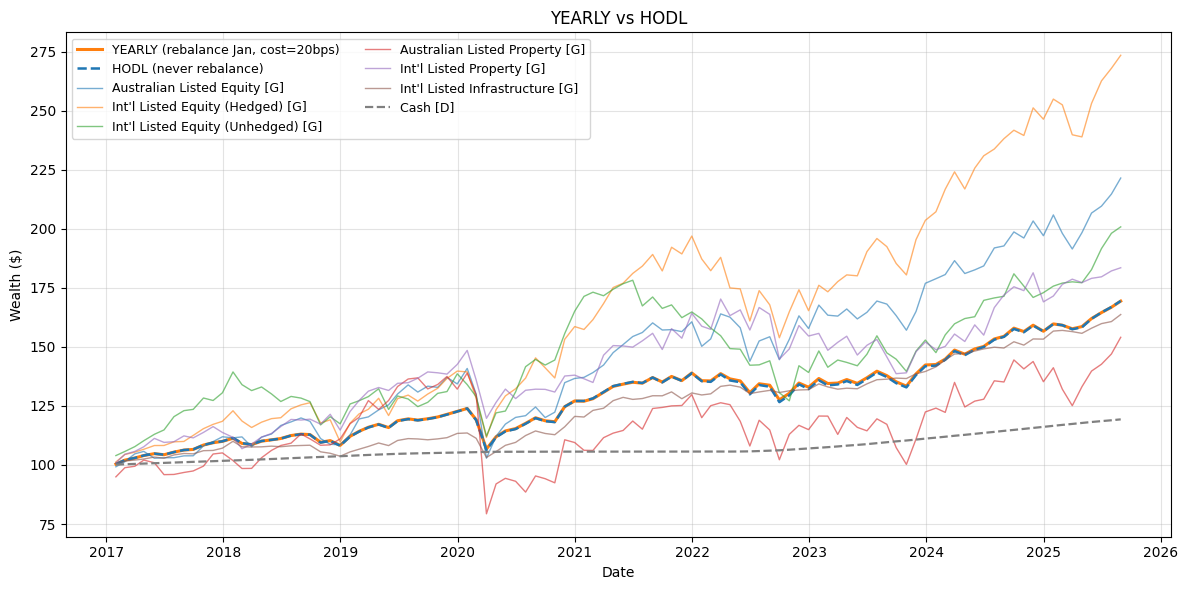

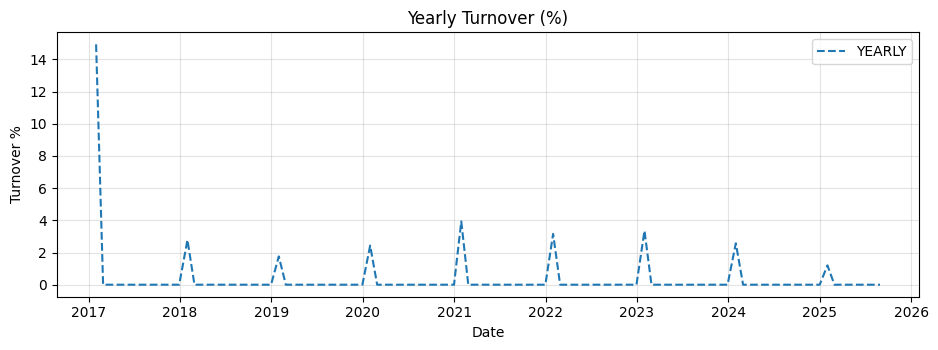

YEARLY  | Ann=0.0655  Vol=0.0708  Sharpe≈0.93  MaxDD=-13.87%
HODL    | Ann=0.0657  Vol=0.0727  Sharpe≈0.90  MaxDD=-14.18%

[Params] phi=0.7, gamma=1.0, bounds=[-0.3,0.3]
PCA80% rank=1, explained≈63.7%
Risk-Attribution penalty=True, λrp=5.0
Trading cost=0.0020 per 1×TO on total wealth


In [110]:
# ============================================
# Only YEARLY and HODL portfolios
# - μ, Σ frozen before backtest
# - YEARLY: rebalance once per year (with cost)
# - HODL: buy once, never rebalance
# - Risk attribution penalty active
# ============================================

# -------- User settings --------
phi            = 0.7
gamma          = 1.0
start_year     = 2017
end_year       = 2025
mu_years       = 10
sg_years       = 3
explained_thr  = 0.80
ridge_eps      = 1e-6
initial_wealth = 100.0

# box constraints for risky weights
wmin, wmax     = -0.3, 0.3
# trading cost (per 1× turnover on total wealth)
tc_rate        = 0.002  # 20 bps

# risk-attribution penalty
risk_attr_on   = True
lambda_rp      = 5.0     # penalty strength
risk_target    = 'equal' # equal risk contributions
q_target       = None
eta_turnover   = 0.0     # optional L2 smoothing
anchor_month   = 1       # rebalance every January

# -------- Imports --------
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize

# -------- Column cleaning (df already loaded) --------
risky_cols = [c for c in df.columns if "[G]" in str(c)]
if not risky_cols:
    raise ValueError("No risky asset columns found with [G].")

cash_candidates = [c for c in df.columns if re.search(r'cash', str(c), flags=re.IGNORECASE)]
cash_col = cash_candidates[0] if cash_candidates else None

date_cols = [c for c in df.columns if re.search(r'date', str(c), flags=re.IGNORECASE)]
data = df.copy()
if date_cols:
    try:
        data.index = pd.to_datetime(df[date_cols[0]])
    except Exception:
        pass
data = data.sort_index()

use_cols = risky_cols + ([cash_col] if cash_col else [])
data = data[use_cols].apply(pd.to_numeric, errors="coerce")
med_abs = data.replace([np.inf, -np.inf], np.nan).abs().stack().median()
if pd.notna(med_abs) and med_abs > 0.5:
    data = data / 100.0
data = data.dropna(how="all").fillna(0.0)

# -------- Helpers --------
def year_slice(df, y0, y1):
    s, e = pd.Timestamp(f"{y0}-01-01"), pd.Timestamp(f"{y1}-12-31")
    return df[(df.index>=s) & (df.index<=e)].copy()

def hist_mean_mu(X_mu: pd.DataFrame):
    return X_mu.mean(axis=0).values

def pca_covariance_80(X_sg: pd.DataFrame, explained_thr=0.80, ridge_eps=1e-6):
    Xc = X_sg - X_sg.mean(axis=0)
    T, N = Xc.shape
    if T < 2:
        S = np.diag(Xc.var(axis=0, ddof=1).values)
        return S + ridge_eps*np.eye(N), 0, 0.0
    U, s, Vt = np.linalg.svd(Xc.values, full_matrices=False)
    eig = (s**2)/(max(T-1,1))
    total = eig.sum()
    if total<=0:
        S = np.diag(Xc.var(axis=0, ddof=1).values)
        return S + ridge_eps*np.eye(N), 0, 0.0
    cume = np.cumsum(eig)
    r = int(np.searchsorted(cume/total, explained_thr))
    r = max(0, min(r, min(T,N)))
    Vr = Vt[:r,:].T
    low = Vr @ np.diag(eig[:r]) @ Vr.T if r>0 else np.zeros((N,N))
    Fr = U[:,:r]*s[:r] if r>0 else np.zeros((T,r))
    resid = Xc.values - Fr@Vr.T if r>0 else Xc.values
    diag = resid.var(axis=0, ddof=1)
    Sigma = low + np.diag(diag) + ridge_eps*np.eye(N)
    explained = float(cume[r-1]/total) if r>0 else 0.0
    return Sigma, r, explained

def drift_weights(w_post, r_prev_vec, phi, r_prev_cash):
    risky_val = phi * w_post * (1.0 + (0.0 if r_prev_vec  is None else r_prev_vec))
    cash_val  = (1.0 - phi) * (1.0 + (0.0 if r_prev_cash is None else r_prev_cash))
    total = cash_val + risky_val.sum()
    risky_weight_total = risky_val / total
    share = risky_weight_total.sum()
    return (risky_weight_total / share) if share > 0 else w_post

def prc_percent(w, Sigma, eps=1e-12):
    Sw = Sigma @ w
    v = float(w @ Sw)
    if abs(v)<eps:
        return np.zeros_like(w)
    return (w*Sw)/v

def solve_box_qp_with_risk_attr(mu_vec, Sigma, c_penalty,
                                wmin=-0.3, wmax=0.3,
                                w_pre=None, eta=0.0,
                                risk_attr_on=True, lambda_rp=0.0,
                                q_target=None, eps=1e-10):
    n = len(mu_vec)
    Sig = Sigma
    ones = np.ones(n)
    if q_target is None:
        q = np.ones(n)/n
    else:
        q = np.asarray(q_target,float)
        q = np.clip(q,0,np.inf)
        q = q/q.sum() if q.sum()>0 else np.ones(n)/n
    w0 = ones/n if w_pre is None else w_pre.copy()
    w0 = np.clip(w0,wmin,wmax); w0=w0/w0.sum()

    def obj(w):
        quad=0.5*c_penalty*(w@Sig@w); lin=-(mu_vec@w)
        l2=0.0 if (w_pre is None or eta<=0) else eta*np.sum((w-w_pre)**2)
        if risk_attr_on and lambda_rp>0:
            Sw=Sig@w; v=float(w@Sw)
            if abs(v)<eps: pen=0.0
            else:
                prc=(w*Sw)/v; pen=np.sum((prc-q)**2)
            return quad+lin+l2+lambda_rp*pen
        return quad+lin+l2
    cons=[{'type':'eq','fun':lambda w:np.sum(w)-1.0}]
    bnds=[(wmin,wmax)]*n
    res=minimize(obj,w0,method='SLSQP',bounds=bnds,constraints=cons,
                 options={'maxiter':400,'ftol':1e-12})
    w=np.clip(res.x,wmin,wmax); w=w/w.sum()
    return w

# -------- Freeze μ & Σ --------
panel = data.copy()
live  = year_slice(panel, start_year, end_year)
first_live = live.index.min()
mu_start = first_live - pd.DateOffset(years=mu_years)
sg_start = first_live - pd.DateOffset(years=sg_years)
X_mu0 = panel.loc[(panel.index>=mu_start)&(panel.index<first_live),risky_cols]
X_sg0 = panel.loc[(panel.index>=sg_start)&(panel.index<first_live),risky_cols]
mu_hat = hist_mean_mu(X_mu0)
Sigma_hat, r_used0, explained0 = pca_covariance_80(X_sg0,explained_thr,ridge_eps)
print(f"[Frozen] PCA rank={r_used0}, explained≈{explained0:.1%}")

# -------- Run YEARLY & HODL --------
idx = pd.DatetimeIndex(live.index,name="date")
n=len(risky_cols); eq_w=np.ones(n)/n

wealth_hodl, wealth_yearly=[],[]
turn_yearly=[]
F_hodl=F_yearly=1.0
w_post_hodl=w_post_yearly=None
r_prev_vec_hodl=r_prev_cash_hodl=None
r_prev_vec_yearly=r_prev_cash_yearly=None

for t in idx:
    r_vec_t = live.loc[t,risky_cols].values
    r_cash_t= float(live.loc[t,cash_col]) if cash_col else 0.0

    # HODL
    if w_post_hodl is None:
        c0=gamma*F_hodl*phi
        w_post_hodl=solve_box_qp_with_risk_attr(
            mu_hat,Sigma_hat,c_penalty=c0,
            wmin=wmin,wmax=wmax,w_pre=eq_w,
            risk_attr_on=risk_attr_on,lambda_rp=lambda_rp)
    w_pre_hodl=drift_weights(w_post_hodl,r_prev_vec_hodl,phi,r_prev_cash_hodl) if r_prev_vec_hodl is not None else w_post_hodl
    w_post_hodl=w_pre_hodl.copy()
    ret_hodl=(1-phi)*r_cash_t+phi*float(np.dot(w_post_hodl,r_vec_t))
    F_hodl*=(1+ret_hodl)
    wealth_hodl.append(initial_wealth*F_hodl)
    r_prev_vec_hodl,r_prev_cash_hodl=r_vec_t,r_cash_t

    # YEARLY
    w_pre_yearly=eq_w if w_post_yearly is None else drift_weights(w_post_yearly,r_prev_vec_yearly,phi,r_prev_cash_yearly)
    is_rebalance_month=(t.month==anchor_month)
    if is_rebalance_month:
        c_yr=gamma*F_yearly*phi
        w_star_yearly=solve_box_qp_with_risk_attr(
            mu_hat,Sigma_hat,c_penalty=c_yr,
            wmin=wmin,wmax=wmax,w_pre=w_pre_yearly,
            risk_attr_on=risk_attr_on,lambda_rp=lambda_rp)
        need_turn_yr=0.5*float(np.sum(np.abs(w_star_yearly-w_pre_yearly)))
        cost_frac_yr=tc_rate*phi*need_turn_yr
        F_yearly*=(1-cost_frac_yr)
        w_post_yearly=w_star_yearly.copy()
        to_yr=need_turn_yr
    else:
        w_post_yearly=w_pre_yearly.copy(); to_yr=0.0
    ret_yearly=(1-phi)*r_cash_t+phi*float(np.dot(w_post_yearly,r_vec_t))
    F_yearly*=(1+ret_yearly)
    wealth_yearly.append(initial_wealth*F_yearly)
    turn_yearly.append(to_yr)
    r_prev_vec_yearly,r_prev_cash_yearly=r_vec_t,r_cash_t

# -------- Curves --------
curve=pd.DataFrame({"YEARLY":wealth_yearly,"HODL":wealth_hodl},index=idx)
turn=pd.DataFrame({"YEARLY":turn_yearly},index=idx)

# -------- Plot wealth --------
live_aligned=live.loc[idx,:].copy()
asset_wealth=(1.0+live_aligned[risky_cols].fillna(0.0)).cumprod()*initial_wealth
plt.figure(figsize=(12,6))
plt.plot(idx,curve["YEARLY"],lw=2.2,color='tab:orange',label=f"YEARLY (rebalance Jan, cost={tc_rate*1e4:.0f}bps)")
plt.plot(idx,curve["HODL"],lw=1.8,ls='--',color='tab:blue',label="HODL (never rebalance)")
for c in risky_cols:
    plt.plot(idx,asset_wealth[c],lw=1.0,alpha=0.6,label=c)
if cash_col:
    cash_wealth=(1.0+live_aligned[cash_col].fillna(0.0)).cumprod()*initial_wealth
    plt.plot(idx,cash_wealth,lw=1.6,ls='--',color='gray',label=cash_col)
plt.title("YEARLY vs HODL")
plt.xlabel("Date"); plt.ylabel("Wealth ($)")
ax=plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.grid(True,alpha=0.35)
handles,labels=plt.gca().get_legend_handles_labels()
uniq=dict(zip(labels,handles))
plt.legend(uniq.values(),uniq.keys(),ncol=2,fontsize=9)
plt.tight_layout(); plt.show()

# -------- Plot turnover --------
plt.figure(figsize=(9.5,3.6))
plt.plot(idx,np.array(turn["YEARLY"])*100.0,"--",label="YEARLY")
plt.title("Yearly Turnover (%)")
plt.xlabel("Date"); plt.ylabel("Turnover %")
ax=plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.grid(True,alpha=0.35); plt.legend(); plt.tight_layout(); plt.show()

# -------- Performance summary --------
def perf(series):
    r=series.pct_change().dropna()
    if len(r)==0:return np.nan,np.nan,np.nan,np.nan
    ann=(1+r.mean())**12-1
    vol=r.std()*np.sqrt(12)
    sharpe=ann/(vol+1e-12)
    mdd=(series/series.cummax()-1).min()
    return ann,vol,sharpe,mdd

for name in ["YEARLY","HODL"]:
    a,v,s,m=perf(curve[name])
    print(f"{name:7s} | Ann={a:.4f}  Vol={v:.4f}  Sharpe≈{s:.2f}  MaxDD={m:.2%}")

print(f"\n[Params] phi={phi}, gamma={gamma}, bounds=[{wmin},{wmax}]")
print(f"PCA80% rank={r_used0}, explained≈{explained0:.1%}")
print(f"Risk-Attribution penalty={risk_attr_on}, λrp={lambda_rp}")
print(f"Trading cost={tc_rate:.4f} per 1×TO on total wealth")


[Frozen] PCA rank=1, explained≈63.7%

=== Realized Sharpe (since purchase date; excess over Cash for portfolios) ===
YEARLY  | N=103  AnnMean=0.0441  AnnVol=0.0706  Sharpe=0.62  Sharpe(Lo-adj)=0.86
HODL    | N=103  AnnMean=0.0443  AnnVol=0.0725  Sharpe=0.61  Sharpe(Lo-adj)=0.84
CASH    | N=103  AnnMean=0.0206  AnnVol=0.0046  Sharpe=4.50  Sharpe(Lo-adj)=1.53


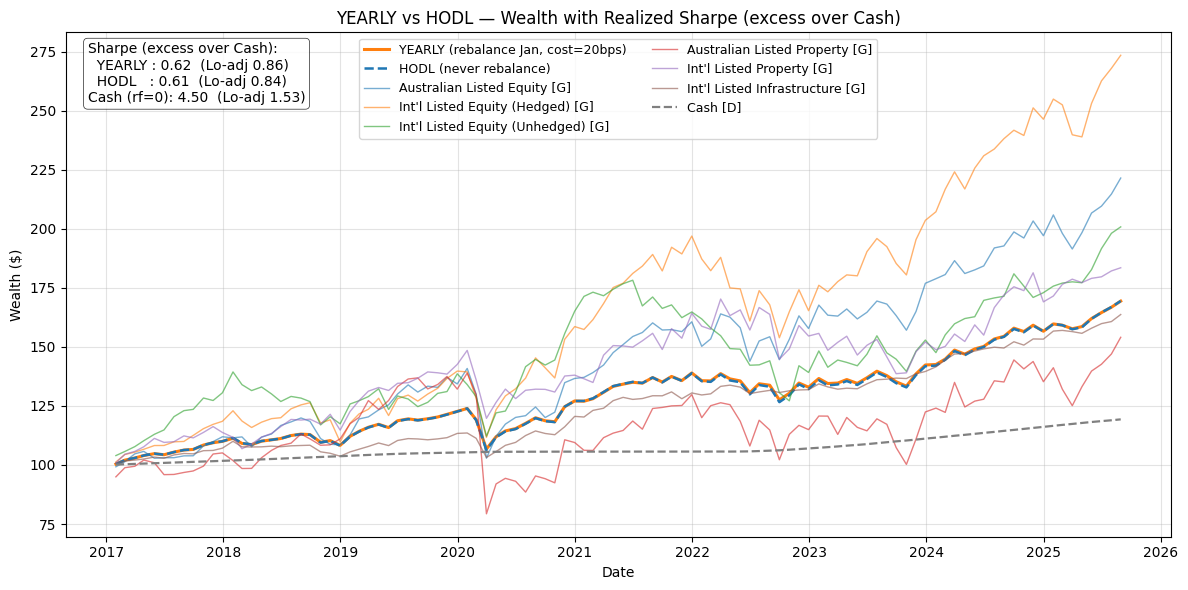

YEARLY  | Ann=0.0655  Vol=0.0708  Sharpe≈0.93  MaxDD=-13.87%
HODL    | Ann=0.0657  Vol=0.0727  Sharpe≈0.90  MaxDD=-14.18%

[Params] phi=0.7, gamma=1.0, bounds=[-0.3,0.3]
PCA80% rank=1, explained≈63.7%
Risk-Attribution penalty=True, λrp=5.0
Trading cost=0.0020 per 1×TO on total wealth


In [125]:
# ============================================
# Only YEARLY and HODL portfolios + TRUE SHARPE ON PLOT
# - μ, Σ frozen before backtest
# - YEARLY: rebalance once per year (with cost)
# - HODL: buy once, never rebalance
# - Risk attribution penalty active (optional)
# - Compute realized Sharpe (excess over Cash) from the plotted wealth paths
#   and annotate on the wealth chart
# ============================================

# -------- User settings --------
phi            = 0.7
gamma          = 1.0
start_year     = 2017
end_year       = 2025
mu_years       = 10
sg_years       = 3
explained_thr  = 0.80
ridge_eps      = 1e-6
initial_wealth = 100.0

# box constraints for risky weights
wmin, wmax     = -0.3, 0.3
# trading cost (per 1× turnover on total wealth)
tc_rate        = 0.002  # 20 bps

# risk-attribution penalty
risk_attr_on   = True
lambda_rp      = 5.0     # penalty strength
risk_target    = 'equal' # equal risk contributions
q_target       = None
eta_turnover   = 0.0     # optional L2 smoothing
anchor_month   = 1       # rebalance every January

# -------- Imports --------
import numpy as np
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize

# -------- Column cleaning (df already loaded) --------
risky_cols = [c for c in df.columns if "[G]" in str(c)]
if not risky_cols:
    raise ValueError("No risky asset columns found with [G].")

cash_candidates = [c for c in df.columns if re.search(r'cash', str(c), flags=re.IGNORECASE)]
cash_col = cash_candidates[0] if cash_candidates else None
if cash_col is None:
    print("[WARN] No Cash column found; Sharpe will be vs rf=0.")

date_cols = [c for c in df.columns if re.search(r'date', str(c), flags=re.IGNORECASE)]
data = df.copy()
if date_cols:
    try:
        data.index = pd.to_datetime(df[date_cols[0]])
    except Exception:
        pass
data = data.sort_index()

use_cols = risky_cols + ([cash_col] if cash_col else [])
data = data[use_cols].apply(pd.to_numeric, errors="coerce")
med_abs = data.replace([np.inf, -np.inf], np.nan).abs().stack().median()
if pd.notna(med_abs) and med_abs > 0.5:
    data = data / 100.0
data = data.dropna(how="all").fillna(0.0)

# -------- Helpers --------
def year_slice(df, y0, y1):
    s, e = pd.Timestamp(f"{y0}-01-01"), pd.Timestamp(f"{y1}-12-31")
    return df[(df.index>=s) & (df.index<=e)].copy()

def hist_mean_mu(X_mu: pd.DataFrame):
    return X_mu.mean(axis=0).values

def pca_covariance_80(X_sg: pd.DataFrame, explained_thr=0.80, ridge_eps=1e-6):
    Xc = X_sg - X_sg.mean(axis=0)
    T, N = Xc.shape
    if T < 2:
        S = np.diag(Xc.var(axis=0, ddof=1).values)
        return S + ridge_eps*np.eye(N), 0, 0.0
    U, s, Vt = np.linalg.svd(Xc.values, full_matrices=False)
    eig = (s**2)/(max(T-1,1))
    total = eig.sum()
    if total<=0:
        S = np.diag(Xc.var(axis=0, ddof=1).values)
        return S + ridge_eps*np.eye(N), 0, 0.0
    cume = np.cumsum(eig)
    r = int(np.searchsorted(cume/total, explained_thr))
    r = max(0, min(r, min(T,N)))
    if r == 0:
        low = np.zeros((N,N))
        Fr = np.zeros((T,0))
        resid = Xc.values
    else:
        Vr = Vt[:r,:].T
        low = Vr @ np.diag(eig[:r]) @ Vr.T
        Fr  = U[:,:r]*s[:r]
        resid = Xc.values - Fr @ Vr.T
    diag = resid.var(axis=0, ddof=1)
    Sigma = low + np.diag(diag) + ridge_eps*np.eye(N)
    explained = float(cume[r-1]/total) if r>0 else 0.0
    return Sigma, r, explained

def drift_weights(w_post, r_prev_vec, phi, r_prev_cash):
    risky_val = phi * w_post * (1.0 + (0.0 if r_prev_vec  is None else r_prev_vec))
    cash_val  = (1.0 - phi) * (1.0 + (0.0 if r_prev_cash is None else r_prev_cash))
    total = cash_val + risky_val.sum()
    risky_weight_total = risky_val / total
    share = risky_weight_total.sum()
    return (risky_weight_total / share) if share > 0 else w_post

def prc_percent(w, Sigma, eps=1e-12):
    Sw = Sigma @ w
    v = float(w @ Sw)
    if abs(v)<eps:
        return np.zeros_like(w)
    return (w*Sw)/v

def solve_box_qp_with_risk_attr(mu_vec, Sigma, c_penalty,
                                wmin=-0.3, wmax=0.3,
                                w_pre=None, eta=0.0,
                                risk_attr_on=True, lambda_rp=0.0,
                                q_target=None, eps=1e-10):
    n = len(mu_vec)
    Sig = Sigma
    ones = np.ones(n)
    if q_target is None:
        q = np.ones(n)/n
    else:
        q = np.asarray(q_target,float)
        q = np.clip(q,0,np.inf)
        q = q/q.sum() if q.sum()>0 else np.ones(n)/n
    w0 = ones/n if w_pre is None else w_pre.copy()
    w0 = np.clip(w0,wmin,wmax); w0=w0/w0.sum()

    def obj(w):
        quad=0.5*c_penalty*(w@Sig@w); lin=-(mu_vec@w)
        l2=0.0 if (w_pre is None or eta<=0) else eta*np.sum((w-w_pre)**2)
        if risk_attr_on and lambda_rp>0:
            Sw=Sig@w; v=float(w@Sw)
            if abs(v)<eps: pen=0.0
            else:
                prc=(w*Sw)/v; pen=np.sum((prc-q)**2)
            return quad+lin+l2+lambda_rp*pen
        return quad+lin+l2
    cons=[{'type':'eq','fun':lambda w:np.sum(w)-1.0}]
    bnds=[(wmin,wmax)]*n
    res=minimize(obj,w0,method='SLSQP',bounds=bnds,constraints=cons,
                 options={'maxiter':400,'ftol':1e-12})
    if not res.success:
        print("[WARN] QP:", res.message)
    w=np.clip(res.x,wmin,wmax); w=w/w.sum()
    return w

# -------- Freeze μ & Σ --------
panel = data.copy()
live  = year_slice(panel, start_year, end_year)
first_live = live.index.min()
mu_start = first_live - pd.DateOffset(years=mu_years)
sg_start = first_live - pd.DateOffset(years=sg_years)
X_mu0 = panel.loc[(panel.index>=mu_start)&(panel.index<first_live),risky_cols]
X_sg0 = panel.loc[(panel.index>=sg_start)&(panel.index<first_live),risky_cols]
mu_hat = hist_mean_mu(X_mu0)
Sigma_hat, r_used0, explained0 = pca_covariance_80(X_sg0,explained_thr,ridge_eps)
print(f"[Frozen] PCA rank={r_used0}, explained≈{explained0:.1%}")

# -------- Run YEARLY & HODL --------
idx = pd.DatetimeIndex(live.index,name="date")
n=len(risky_cols); eq_w=np.ones(n)/n

wealth_hodl, wealth_yearly=[],[]
turn_yearly=[]
F_hodl=F_yearly=1.0
w_post_hodl=w_post_yearly=None
r_prev_vec_hodl=r_prev_cash_hodl=None
r_prev_vec_yearly=r_prev_cash_yearly=None

for t in idx:
    r_vec_t = live.loc[t,risky_cols].values
    r_cash_t= float(live.loc[t,cash_col]) if cash_col else 0.0

    # HODL
    if w_post_hodl is None:
        c0=gamma*F_hodl*phi
        w_post_hodl=solve_box_qp_with_risk_attr(
            mu_hat,Sigma_hat,c_penalty=c0,
            wmin=wmin,wmax=wmax,w_pre=eq_w,
            risk_attr_on=risk_attr_on,lambda_rp=lambda_rp)
    w_pre_hodl=drift_weights(w_post_hodl,r_prev_vec_hodl,phi,r_prev_cash_hodl) if r_prev_vec_hodl is not None else w_post_hodl
    w_post_hodl=w_pre_hodl.copy()
    ret_hodl=(1-phi)*r_cash_t+phi*float(np.dot(w_post_hodl,r_vec_t))
    F_hodl*=(1+ret_hodl)
    wealth_hodl.append(initial_wealth*F_hodl)
    r_prev_vec_hodl,r_prev_cash_hodl=r_vec_t,r_cash_t

    # YEARLY
    w_pre_yearly=eq_w if w_post_yearly is None else drift_weights(w_post_yearly,r_prev_vec_yearly,phi,r_prev_cash_yearly)
    is_rebalance_month=(t.month==anchor_month)
    if is_rebalance_month:
        c_yr=gamma*F_yearly*phi
        w_star_yearly=solve_box_qp_with_risk_attr(
            mu_hat,Sigma_hat,c_penalty=c_yr,
            wmin=wmin,wmax=wmax,w_pre=w_pre_yearly,
            risk_attr_on=risk_attr_on,lambda_rp=lambda_rp)
        need_turn_yr=0.5*float(np.sum(np.abs(w_star_yearly-w_pre_yearly)))
        cost_frac_yr=tc_rate*phi*need_turn_yr
        F_yearly*=(1-cost_frac_yr)
        w_post_yearly=w_star_yearly.copy()
        to_yr=need_turn_yr
    else:
        w_post_yearly=w_pre_yearly.copy(); to_yr=0.0
    ret_yearly=(1-phi)*r_cash_t+phi*float(np.dot(w_post_yearly,r_vec_t))
    F_yearly*=(1+ret_yearly)
    wealth_yearly.append(initial_wealth*F_yearly)
    turn_yearly.append(to_yr)
    r_prev_vec_yearly,r_prev_cash_yearly=r_vec_t,r_cash_t

# -------- Curves (wealth paths) --------
curve=pd.DataFrame({"YEARLY":wealth_yearly,"HODL":wealth_hodl},index=idx)
turn=pd.DataFrame({"YEARLY":turn_yearly},index=idx)

# -------- True Sharpe from the wealth paths (excess over Cash) --------
def realized_sharpe_from_wealth(wealth: pd.Series,
                                rf_series: pd.Series | None,
                                freq_per_year: int = 12) -> dict:
    r = wealth.pct_change().dropna()
    if rf_series is not None:
        rf_aligned = rf_series.reindex(r.index).fillna(0.0)
        x = r - rf_aligned
    else:
        x = r

    T = len(x)
    if T < 6 or x.std(ddof=1) == 0:
        return {"n_obs": T, "ann_mean": np.nan, "ann_vol": np.nan,
                "sharpe": np.nan, "sharpe_lo": np.nan}

    mx = x.mean()
    sx = x.std(ddof=1)
    ann_mean = (1 + mx)**freq_per_year - 1
    ann_vol  = sx * np.sqrt(freq_per_year)
    sr = ann_mean / (ann_vol + 1e-12)

    # Lo(2002)-adjusted Sharpe (accounts for autocorrelation)
    K = int(np.floor(T**(1/3)))
    if K <= 0:
        sr_lo = sr
    else:
        x0 = x - mx
        denom = float(np.sum(x0**2))
        rho_sum = 0.0
        if denom > 0:
            for k in range(1, K+1):
                num = float(np.sum(x0.iloc[k:].values * x0.iloc[:-k].values))
                rho_k = num / denom
                rho_sum += rho_k
        adj = np.sqrt(max(1.0 + 2.0 * rho_sum, 1e-12))
        sr_lo = sr / adj

    return {"n_obs": T,
            "ann_mean": float(ann_mean),
            "ann_vol":  float(ann_vol),
            "sharpe":   float(sr),
            "sharpe_lo":float(sr_lo)}

# Cash monthly returns aligned to curve
if cash_col is not None:
    rf_series = live.loc[curve.index, cash_col].astype(float)
else:
    rf_series = None

res_yearly = realized_sharpe_from_wealth(curve["YEARLY"], rf_series)
res_hodl   = realized_sharpe_from_wealth(curve["HODL"],   rf_series)

# Cash wealth & Sharpe (rf=0 baseline)
if cash_col is not None:
    cash_wealth = (1.0 + rf_series).cumprod() * initial_wealth
    res_cash    = realized_sharpe_from_wealth(cash_wealth, rf_series=None)
else:
    cash_wealth = None
    res_cash = {"n_obs": np.nan, "ann_mean": np.nan, "ann_vol": np.nan,
                "sharpe": np.nan, "sharpe_lo": np.nan}

print("\n=== Realized Sharpe (since purchase date; excess over Cash for portfolios) ===")
for name, res in [("YEARLY", res_yearly), ("HODL", res_hodl)]:
    print(f"{name:7s} | N={res['n_obs']:3d}  AnnMean={res['ann_mean']:.4f}  "
          f"AnnVol={res['ann_vol']:.4f}  Sharpe={res['sharpe']:.2f}  "
          f"Sharpe(Lo-adj)={res['sharpe_lo']:.2f}")
print(f"CASH    | N={res_cash['n_obs'] if isinstance(res_cash['n_obs'], (int,float)) else 0:3}  "
      f"AnnMean={res_cash['ann_mean']:.4f}  AnnVol={res_cash['ann_vol']:.4f}  "
      f"Sharpe={res_cash['sharpe']:.2f}  Sharpe(Lo-adj)={res_cash['sharpe_lo']:.2f}")

# -------- Plot wealth + annotate TRUE SHARPE --------
live_aligned=live.loc[idx,:].copy()
asset_wealth=(1.0+live_aligned[risky_cols].fillna(0.0)).cumprod()*initial_wealth
cash_wealth_plot = ((1.0 + live_aligned[cash_col]).cumprod() * initial_wealth) if cash_col else None

fig, ax = plt.subplots(figsize=(12,6))
ax.plot(idx,curve["YEARLY"],lw=2.2,color='tab:orange',label=f"YEARLY (rebalance Jan, cost={tc_rate*1e4:.0f}bps)")
ax.plot(idx,curve["HODL"],lw=1.8,ls='--',color='tab:blue',label="HODL (never rebalance)")
for c in risky_cols:
    ax.plot(idx,asset_wealth[c],lw=1.0,alpha=0.6,label=c)
if cash_wealth_plot is not None:
    ax.plot(cash_wealth_plot.index,cash_wealth_plot.values,lw=1.6,ls='--',color='gray',label=cash_col)

ax.set_title("YEARLY vs HODL — Wealth with Realized Sharpe (excess over Cash)")
ax.set_xlabel("Date"); ax.set_ylabel("Wealth ($)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True,alpha=0.35)
handles,labels=plt.gca().get_legend_handles_labels()
uniq=dict(zip(labels,handles))
ax.legend(uniq.values(),uniq.keys(),ncol=2,fontsize=9)

# assemble annotation text
txt = (f"Sharpe (excess over Cash):\n"
       f"  YEARLY : {res_yearly['sharpe']:.2f}  (Lo-adj {res_yearly['sharpe_lo']:.2f})\n"
       f"  HODL   : {res_hodl['sharpe']:.2f}  (Lo-adj {res_hodl['sharpe_lo']:.2f})\n"
       f"Cash (rf=0): {res_cash['sharpe']:.2f}  (Lo-adj {res_cash['sharpe_lo']:.2f})")

ax.text(0.02, 0.98, txt, transform=ax.transAxes,
        va='top', ha='left', fontsize=10,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, lw=0.5))

plt.tight_layout(); plt.show()

# -------- Short perf summary (for quick reference) --------
def perf(series):
    r=series.pct_change().dropna()
    if len(r)==0:return np.nan,np.nan,np.nan,np.nan
    ann=(1+r.mean())**12-1
    vol=r.std()*np.sqrt(12)
    sharpe=ann/(vol+1e-12)
    mdd=(series/series.cummax()-1).min()
    return ann,vol,sharpe,mdd

for name in ["YEARLY","HODL"]:
    a,v,s,m=perf(curve[name])
    print(f"{name:7s} | Ann={a:.4f}  Vol={v:.4f}  Sharpe≈{s:.2f}  MaxDD={m:.2%}")

print(f"\n[Params] phi={phi}, gamma={gamma}, bounds=[{wmin},{wmax}]")
print(f"PCA80% rank={r_used0}, explained≈{explained0:.1%}")
print(f"Risk-Attribution penalty={risk_attr_on}, λrp={lambda_rp}")
print(f"Trading cost={tc_rate:.4f} per 1×TO on total wealth")


In [135]:
import numpy as np
import pandas as pd

_required = ["curve_ext", "live", "cash_col"]
for _x in _required:
    if _x not in globals():
        raise RuntimeError(f"Missing object `{_x}`. Run the backtest cell first.")

run_idx = curve_ext.index.copy()
if cash_col is None:
    raise RuntimeError("No `cash_col` detected. Need a Cash column in df to compute excess returns.")

cash_r = live.loc[run_idx, cash_col].astype(float).fillna(0.0)
port_names = ["THRESH", "YEARLY", "HODL"]
R = {}
for name in port_names:
    if name not in curve_ext.columns:
        raise RuntimeError(f"`curve_ext` does not contain {name}.")
    R[name] = curve_ext[name].pct_change().reindex(run_idx).astype(float)

Rx = {name: (R[name] - cash_r) for name in port_names}

def ann_mean_vol_sharpe(r_excess: pd.Series):
    r = r_excess.dropna()
    if len(r) < 3:
        return np.nan, np.nan, np.nan
    ann_mean = (1.0 + r.mean())**12 - 1.0
    ann_vol  = r.std(ddof=1) * np.sqrt(12.0)
    sharpe   = ann_mean / (ann_vol + 1e-12)
    return ann_mean, ann_vol, sharpe

def lo_adjusted_sharpe(r_excess: pd.Series, base_sharpe: float):
    r = r_excess.dropna()
    n = len(r)
    if n < 12 or not np.isfinite(base_sharpe):
        return np.nan
    x = r - r.mean()
    K = int(np.floor(n**(1/3)))
    if K <= 0:
        return base_sharpe
    ac_sum = 0.0
    denom = float(np.dot(x, x))
    if denom <= 0:
        return base_sharpe
    for k in range(1, K+1):
        num = float(np.dot(x[k:], x[:-k]))
        rho_k = num / denom
        ac_sum += rho_k
    vif = 1.0 + 2.0 * ac_sum
    if vif <= 0:
        return base_sharpe
    return base_sharpe / np.sqrt(vif)

rows = []
for name in port_names:
    ann_m, ann_v, sr = ann_mean_vol_sharpe(Rx[name])
    sr_lo = lo_adjusted_sharpe(Rx[name], sr)
    rows.append([name, len(Rx[name].dropna()), ann_m, ann_v, sr, sr_lo])

ann_m_c, ann_v_c, sr_c = ann_mean_vol_sharpe(cash_r.fillna(0.0))
sr_lo_c = lo_adjusted_sharpe(cash_r.fillna(0.0), sr_c)
rows.append(["CASH(ref vs 0)", len(cash_r.dropna()), ann_m_c, ann_v_c, sr_c, sr_lo_c])

summary = pd.DataFrame(rows, columns=["Series", "N", "AnnMean", "AnnVol", "Sharpe", "Sharpe(Lo-adj)"])

def _fmt(x):
    if isinstance(x, (float, np.floating)):
        return f"{x:,.4f}"
    return str(x)

print("\n=== Realized Sharpe (since purchase; portfolios are excess over Cash) ===")
for _, r in summary.iterrows():
    print(f"{r['Series']:<12s} | N={int(r['N'])}  AnnMean={_fmt(r['AnnMean'])}  AnnVol={_fmt(r['AnnVol'])}  "
          f"Sharpe={_fmt(r['Sharpe'])}  Sharpe(Lo-adj)={_fmt(r['Sharpe(Lo-adj)'])}")



=== Realized Sharpe (since purchase; portfolios are excess over Cash) ===
THRESH       | N=103  AnnMean=0.0905  AnnVol=0.1693  Sharpe=0.5348  Sharpe(Lo-adj)=0.8488
YEARLY       | N=103  AnnMean=0.1041  AnnVol=0.1695  Sharpe=0.6142  Sharpe(Lo-adj)=0.9753
HODL         | N=103  AnnMean=0.0926  AnnVol=0.1307  Sharpe=0.7088  Sharpe(Lo-adj)=1.0295
CASH(ref vs 0) | N=104  AnnMean=0.0206  AnnVol=0.0046  Sharpe=4.5138  Sharpe(Lo-adj)=1.5399
